In [1]:
from code_execution.functions.find_z import find_z_argmax
from resources.archive.cut_off_black_segments import cut_off_black_segments
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd
from resources.smooth_1d import smooth_1d
from resources.find_z import calculate_z_profile, find_z_argmax,find_z_area_center,find_z_center

In [2]:
PROJECT_DIR = Path(r"C:\Users\abram\PycharmProjects\DrivenData_DAT_Parkinsons")
NIFTI_DIR = PROJECT_DIR / "data" / "niftis"
FILE_NAME = "08liuqdn.nii.gz"
FILE_PATH = NIFTI_DIR / FILE_NAME
LABELS_PATH = NIFTI_DIR / "train_labels_JNDlMjr.csv"

labels = pd.read_csv(LABELS_PATH)
files = sorted(NIFTI_DIR.glob("*.nii.gz"))
target_map = labels.set_index("uid")["is_pathologic"].to_dict()

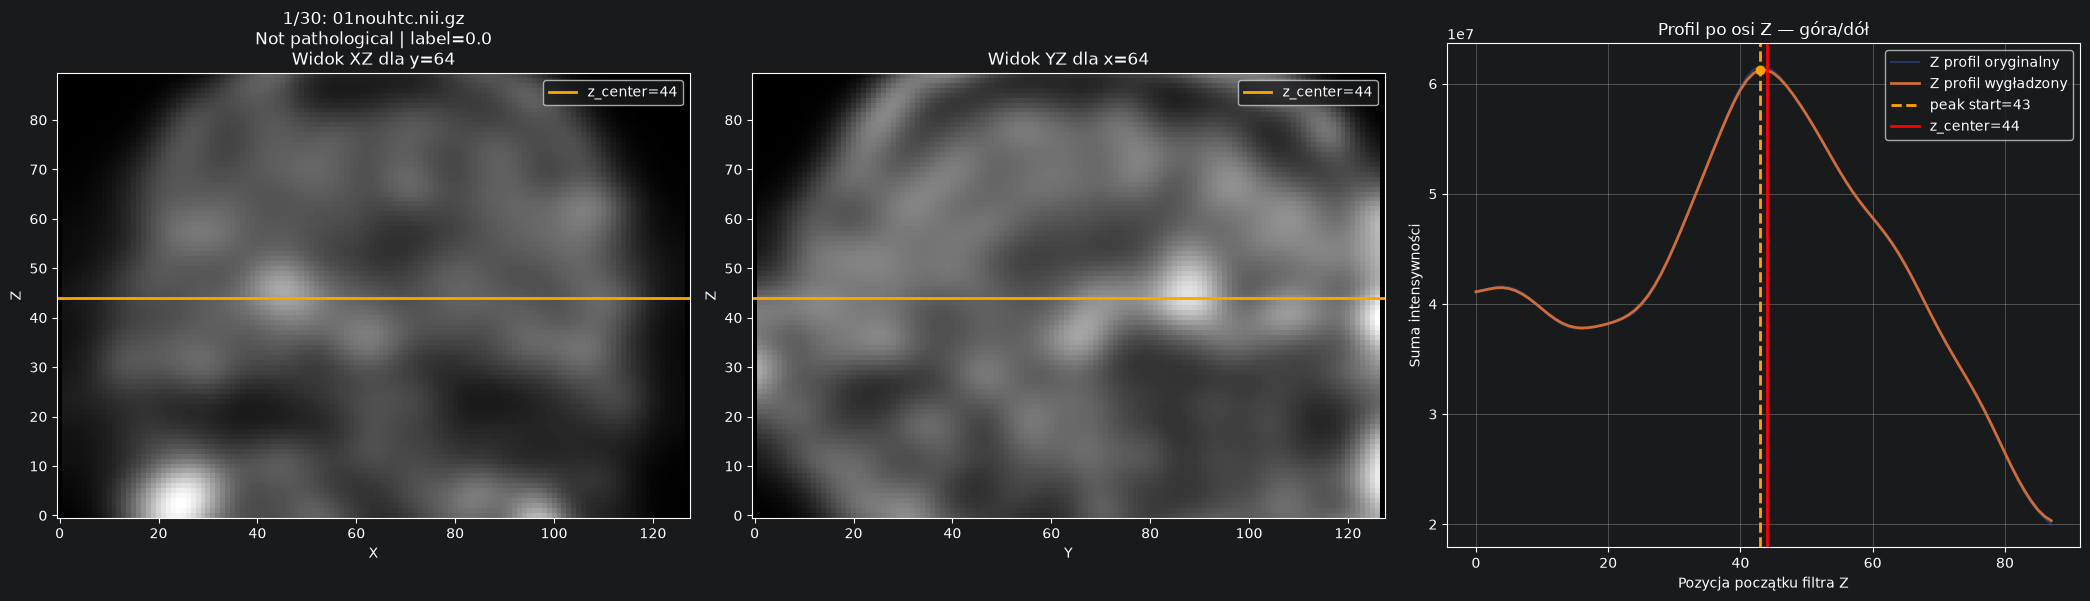

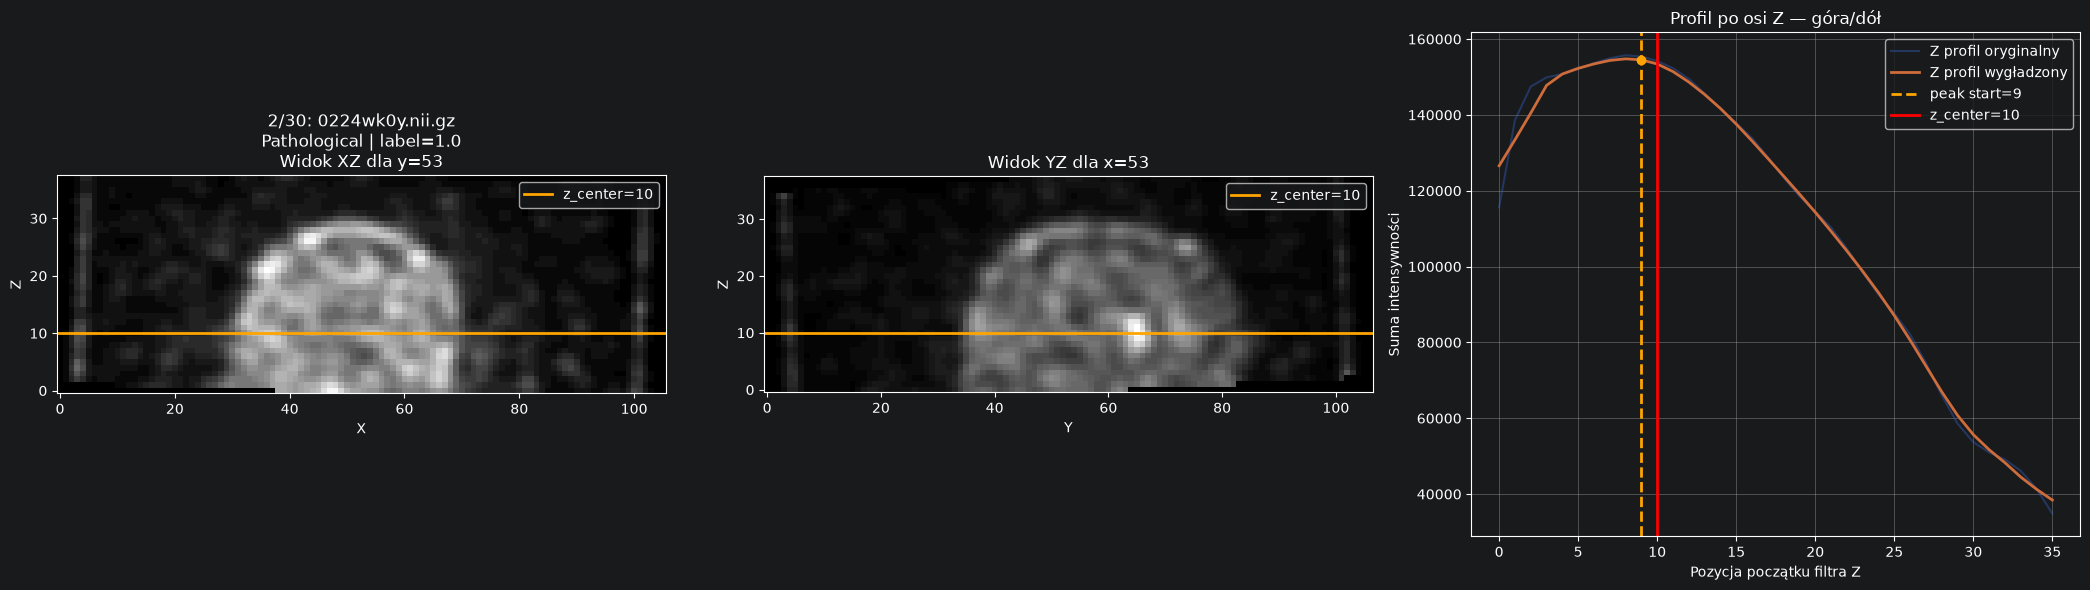

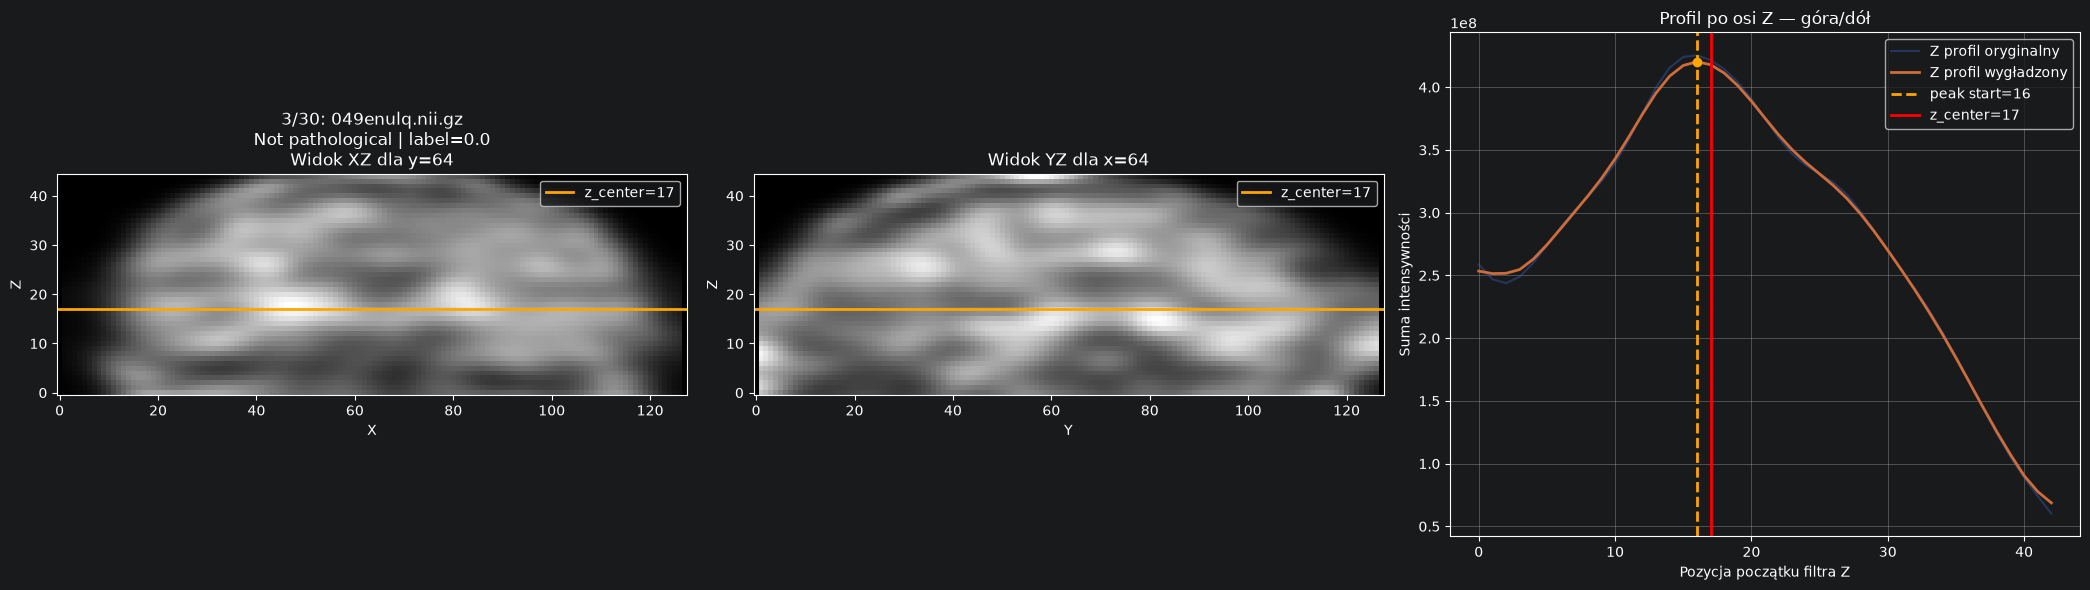

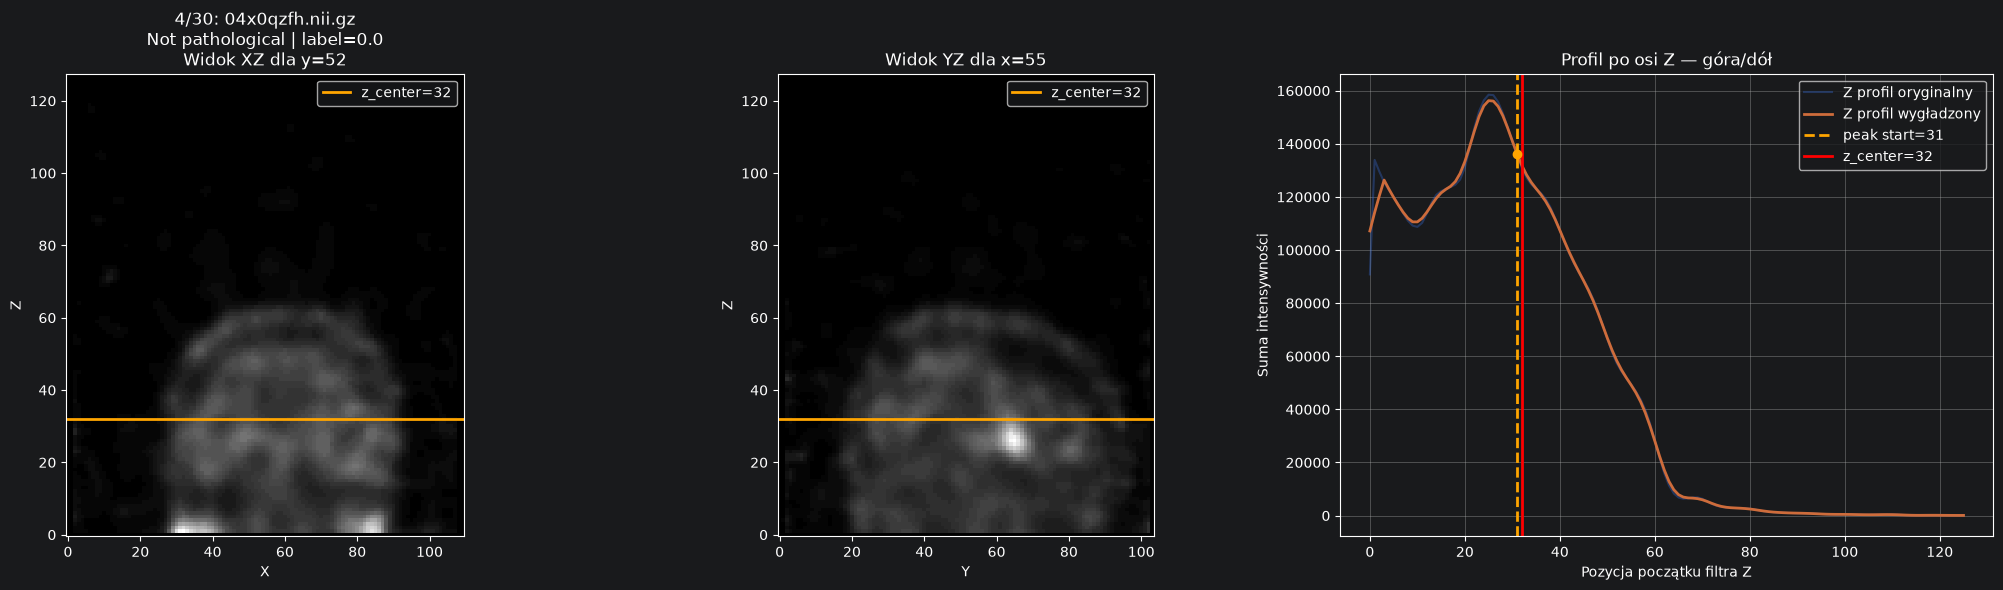

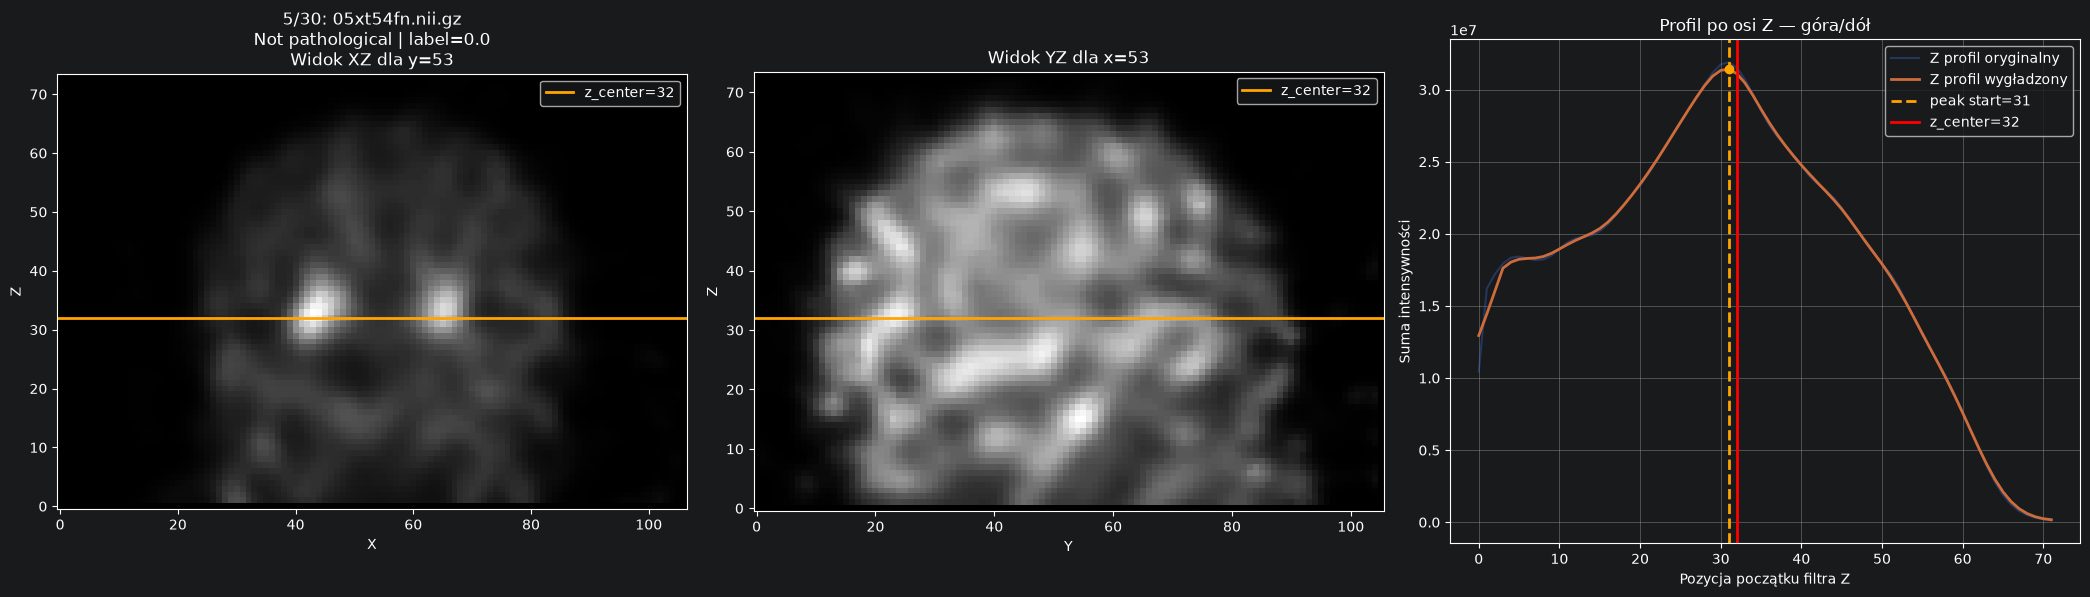

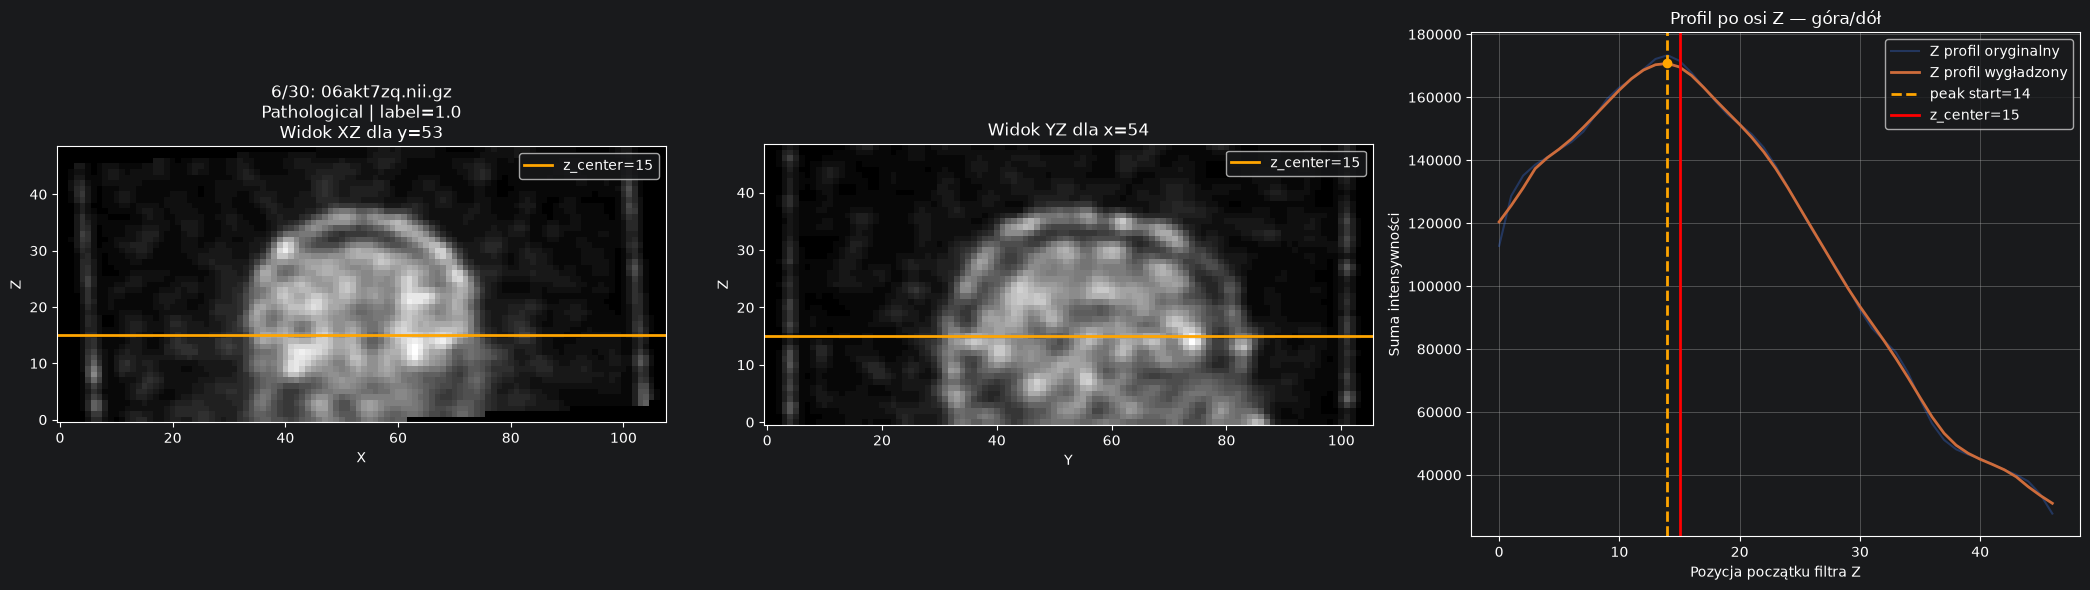

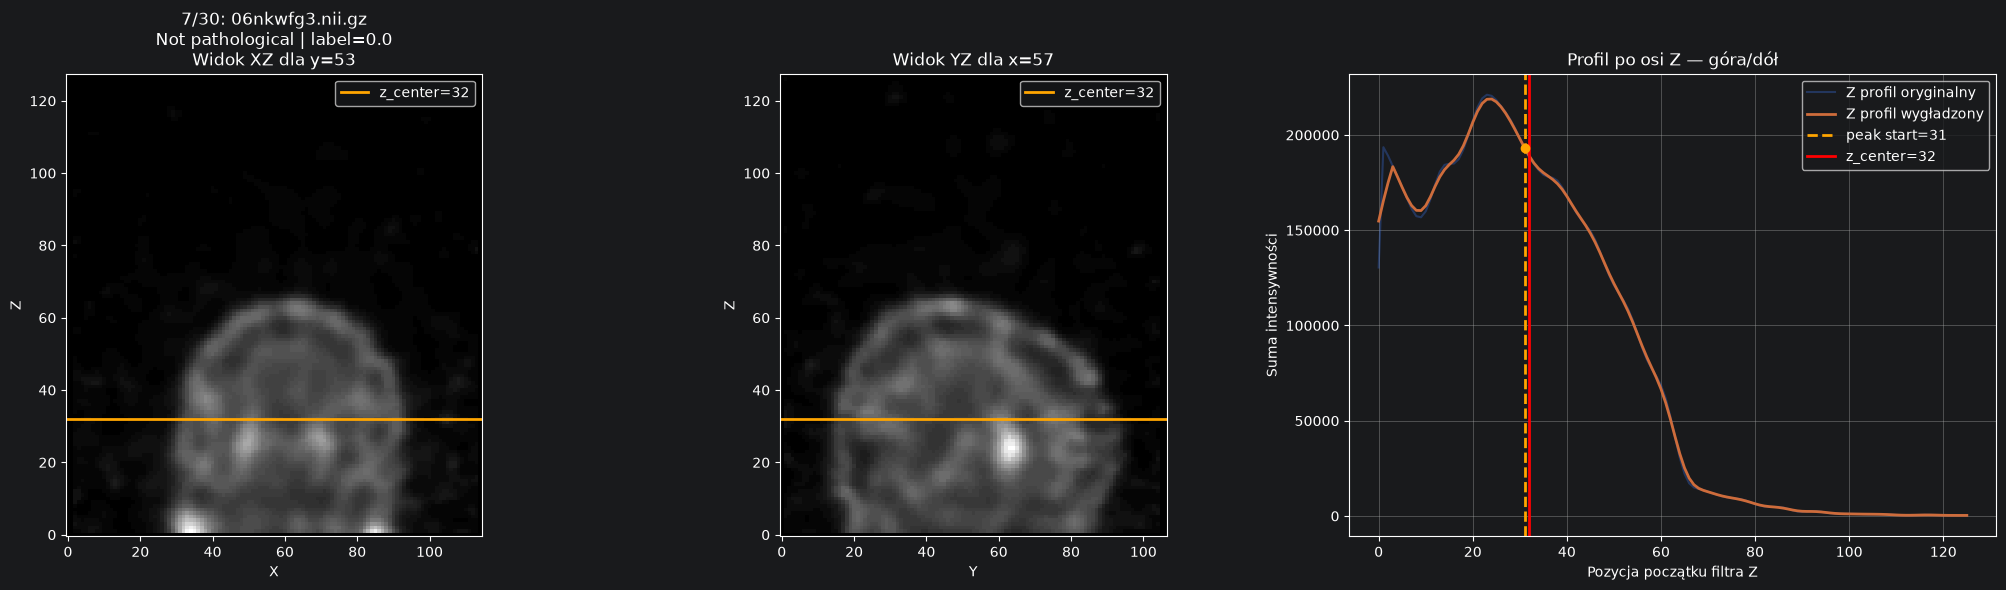

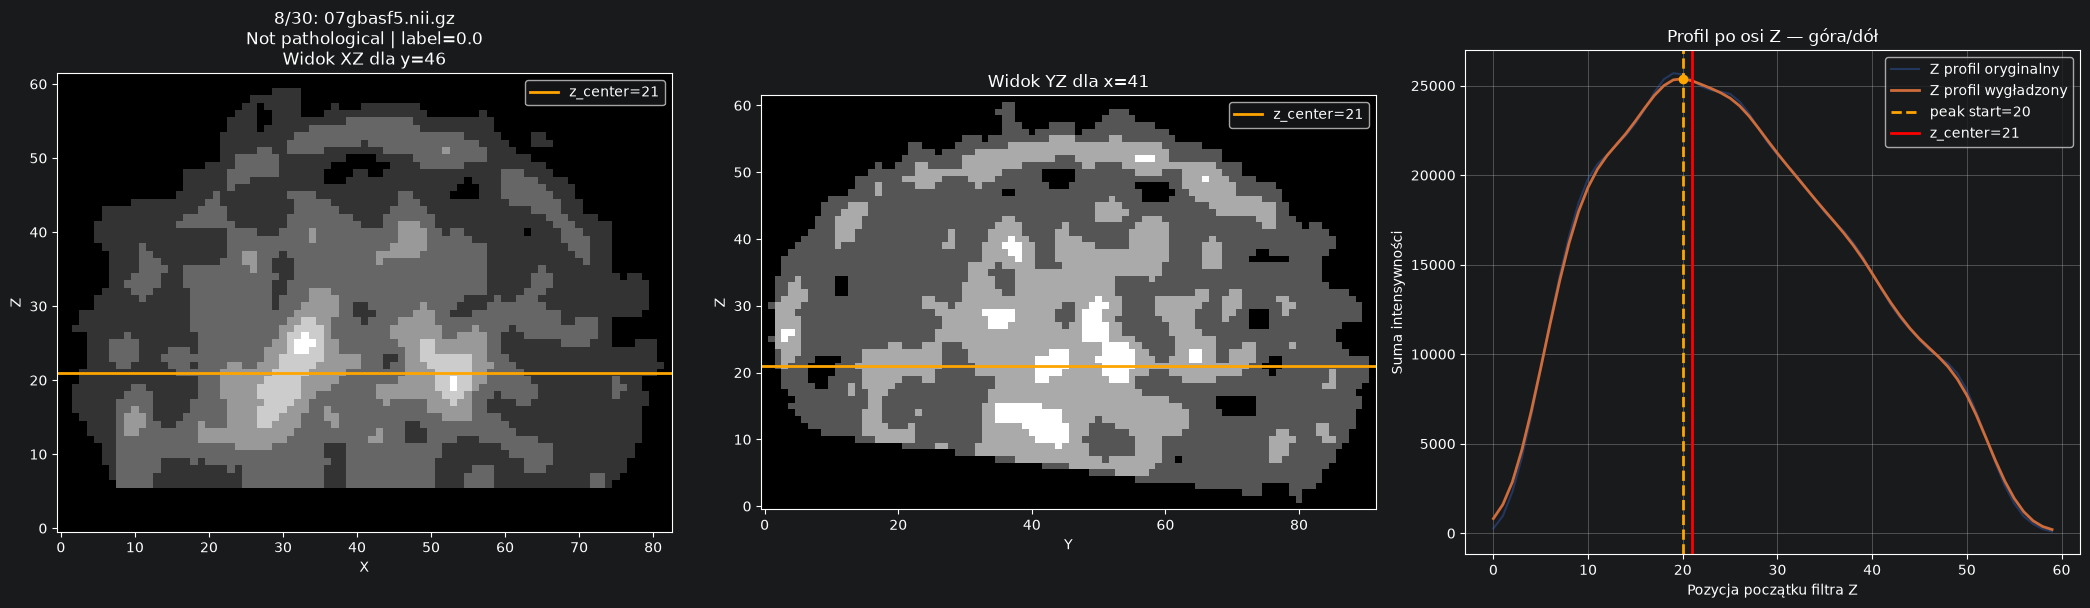

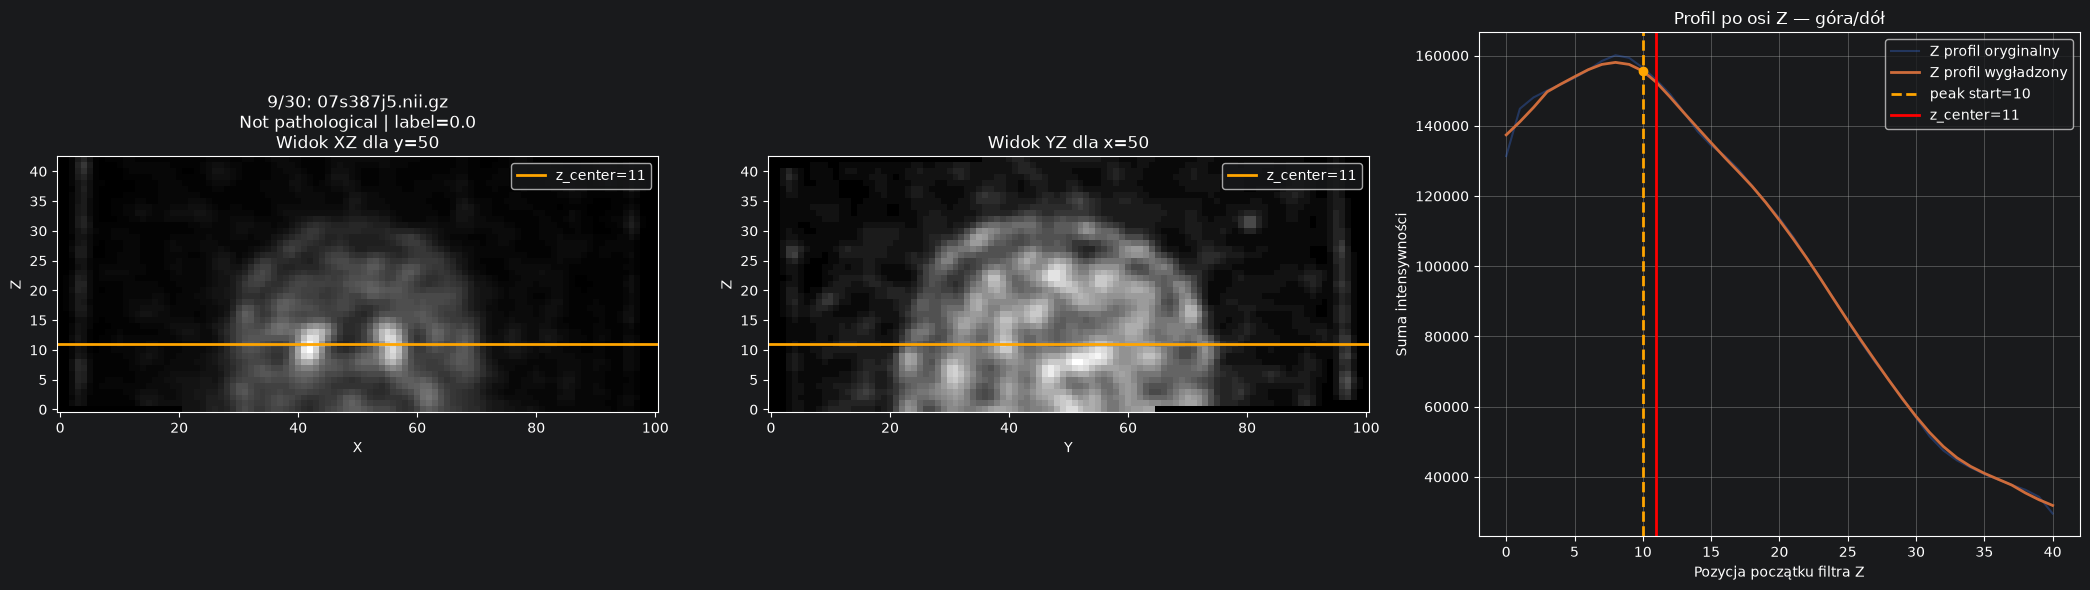

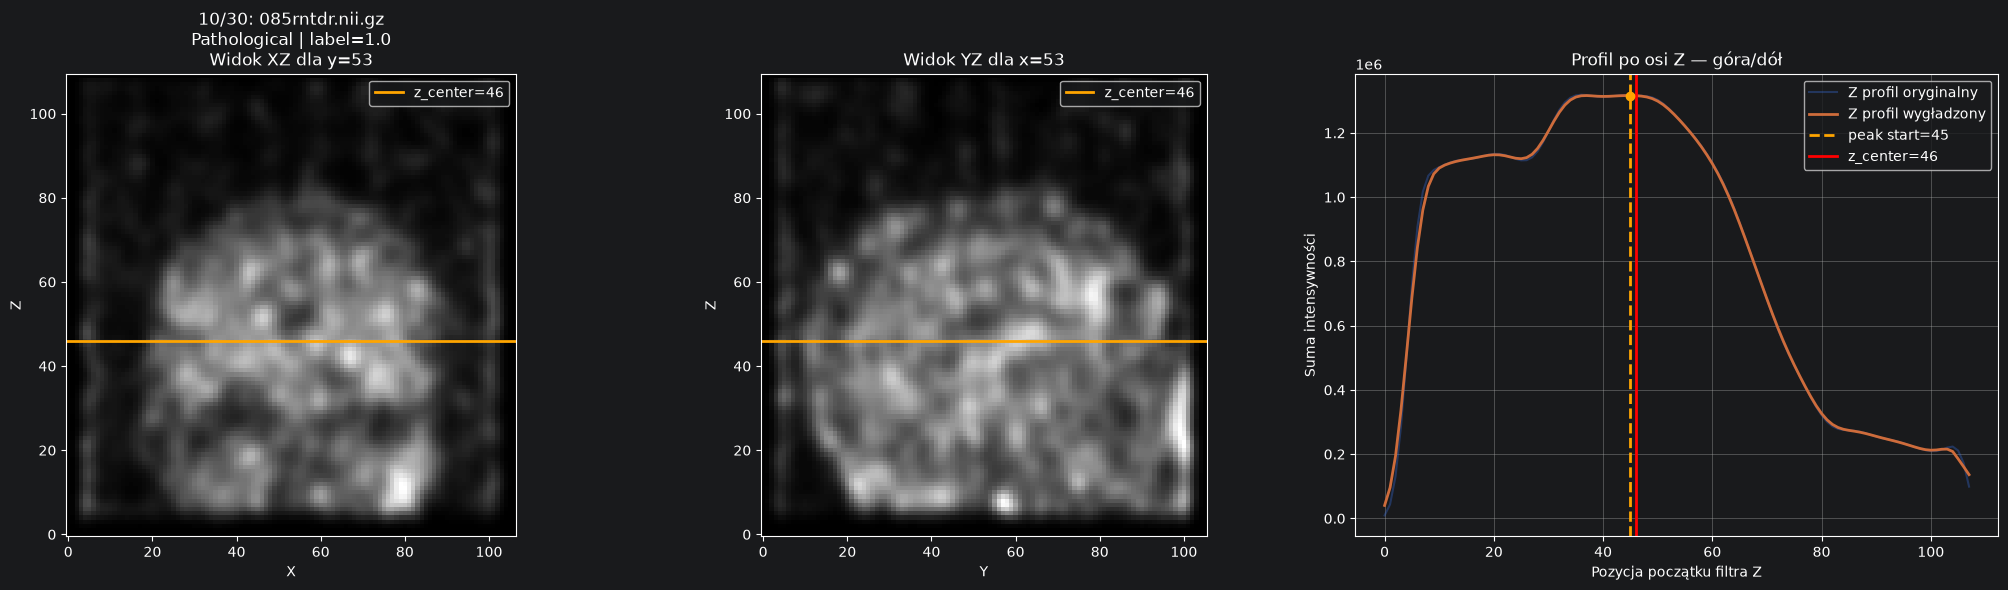

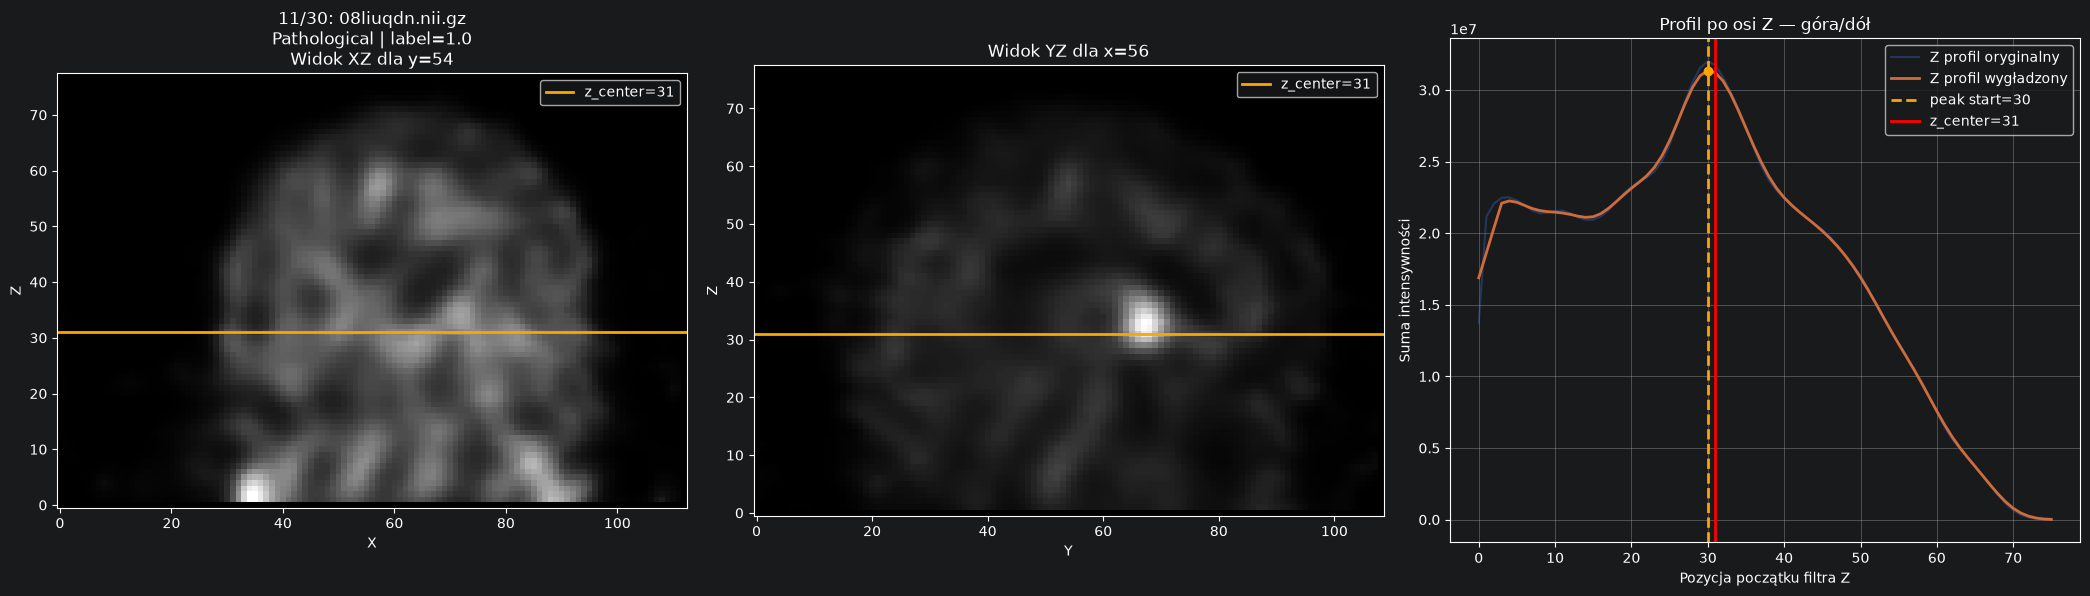

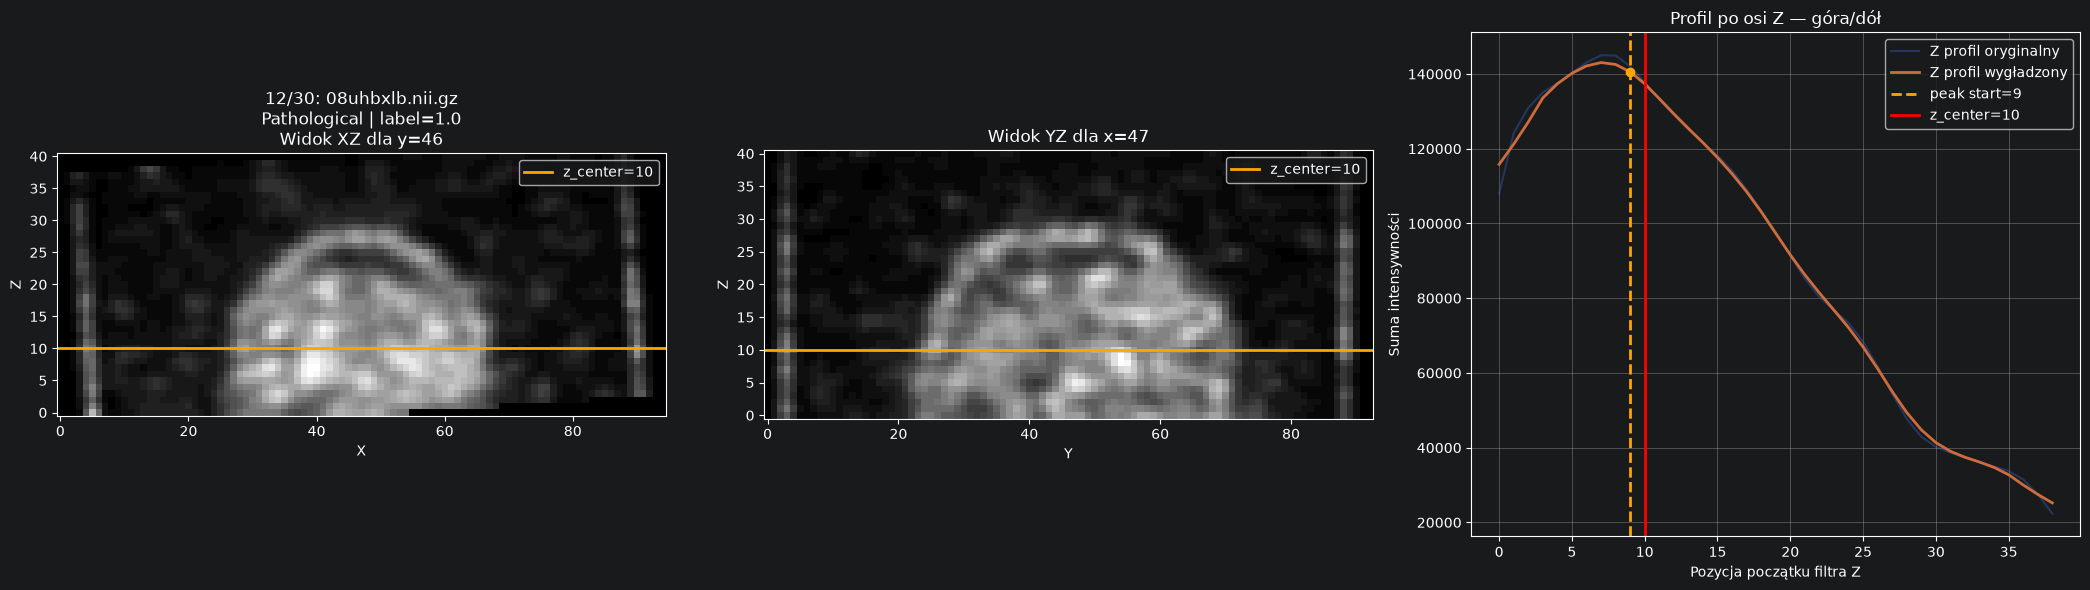

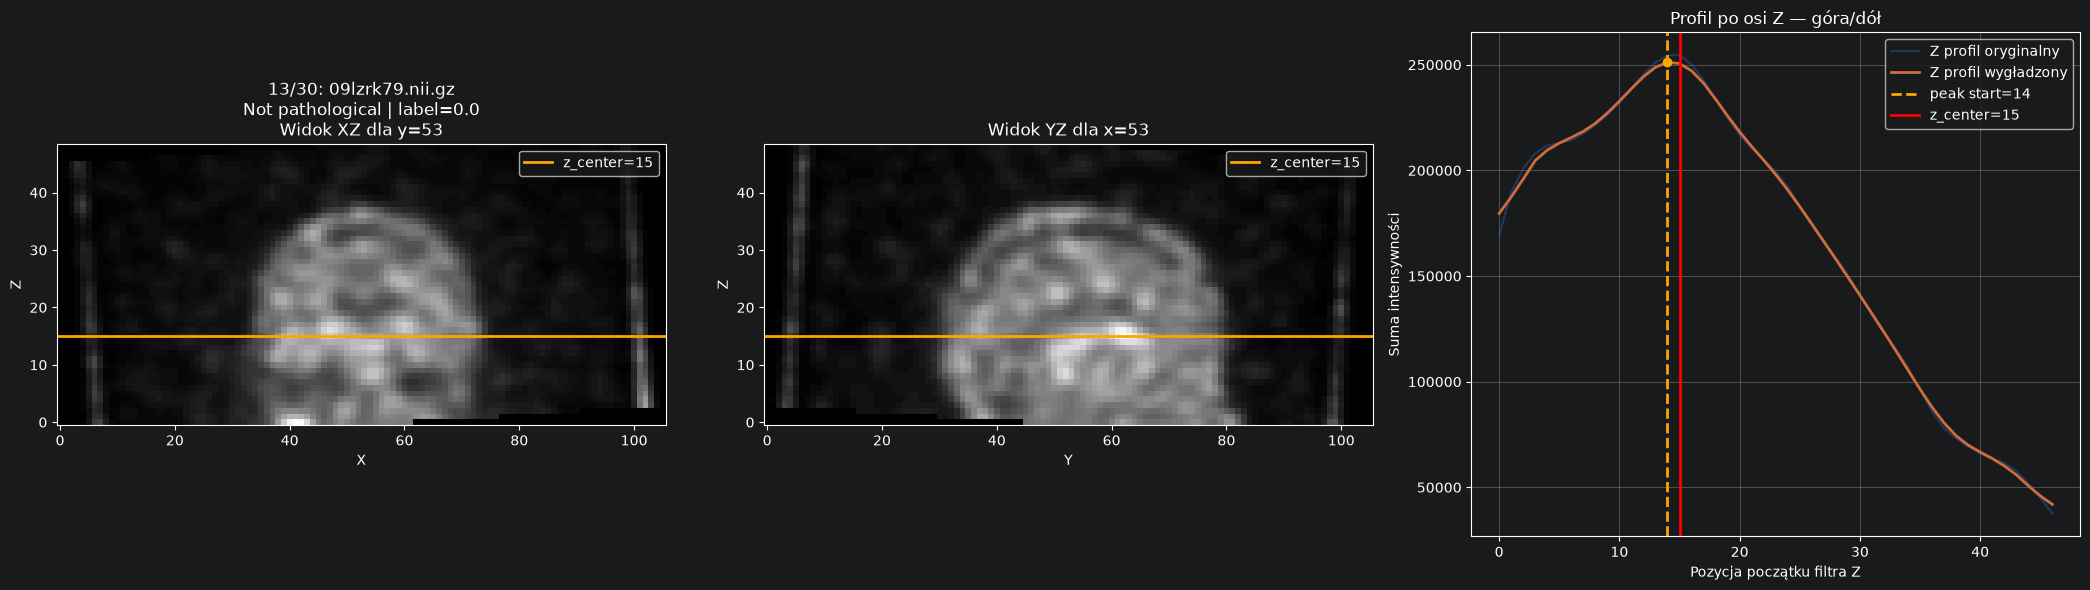

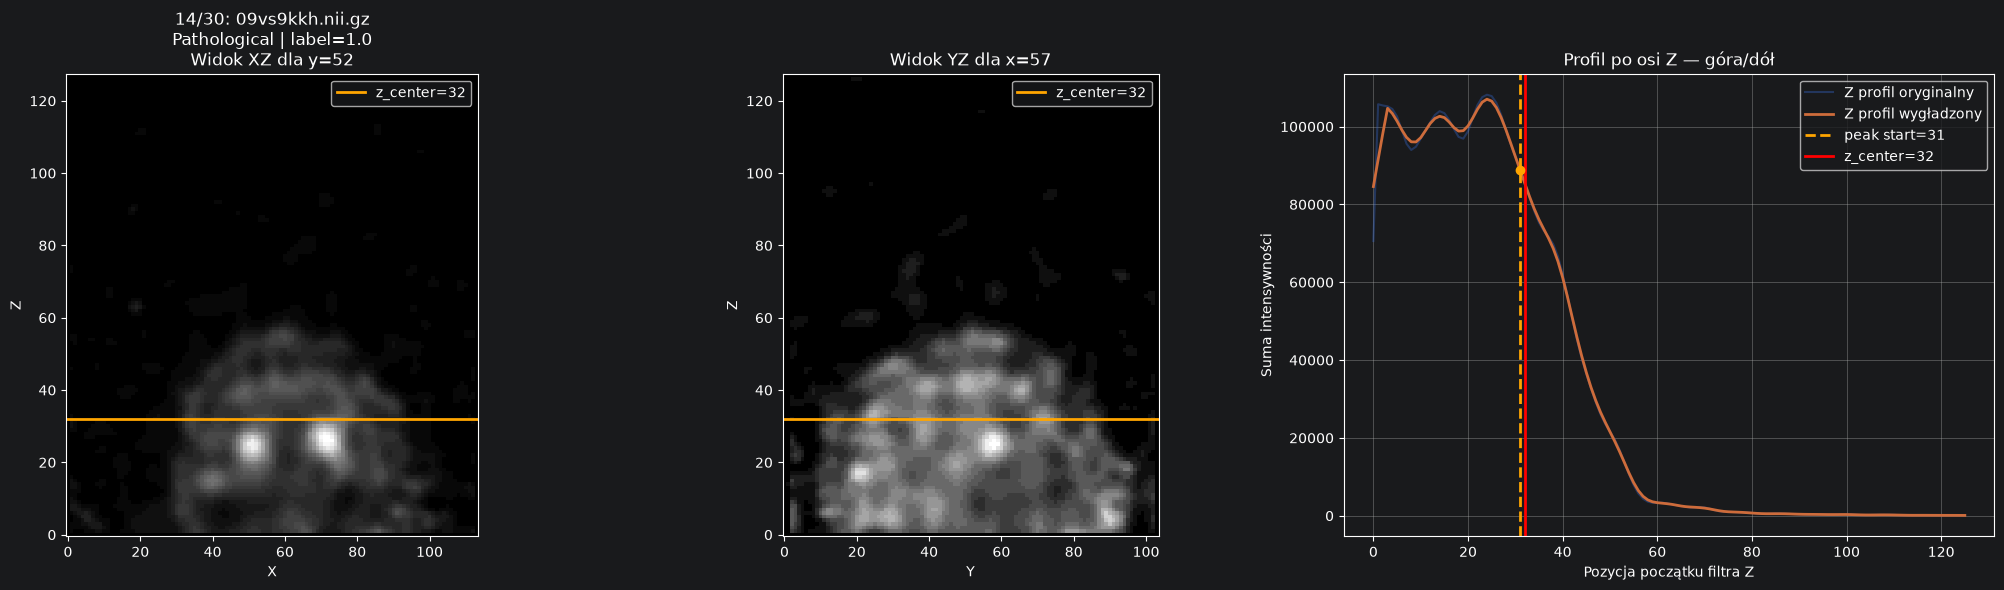

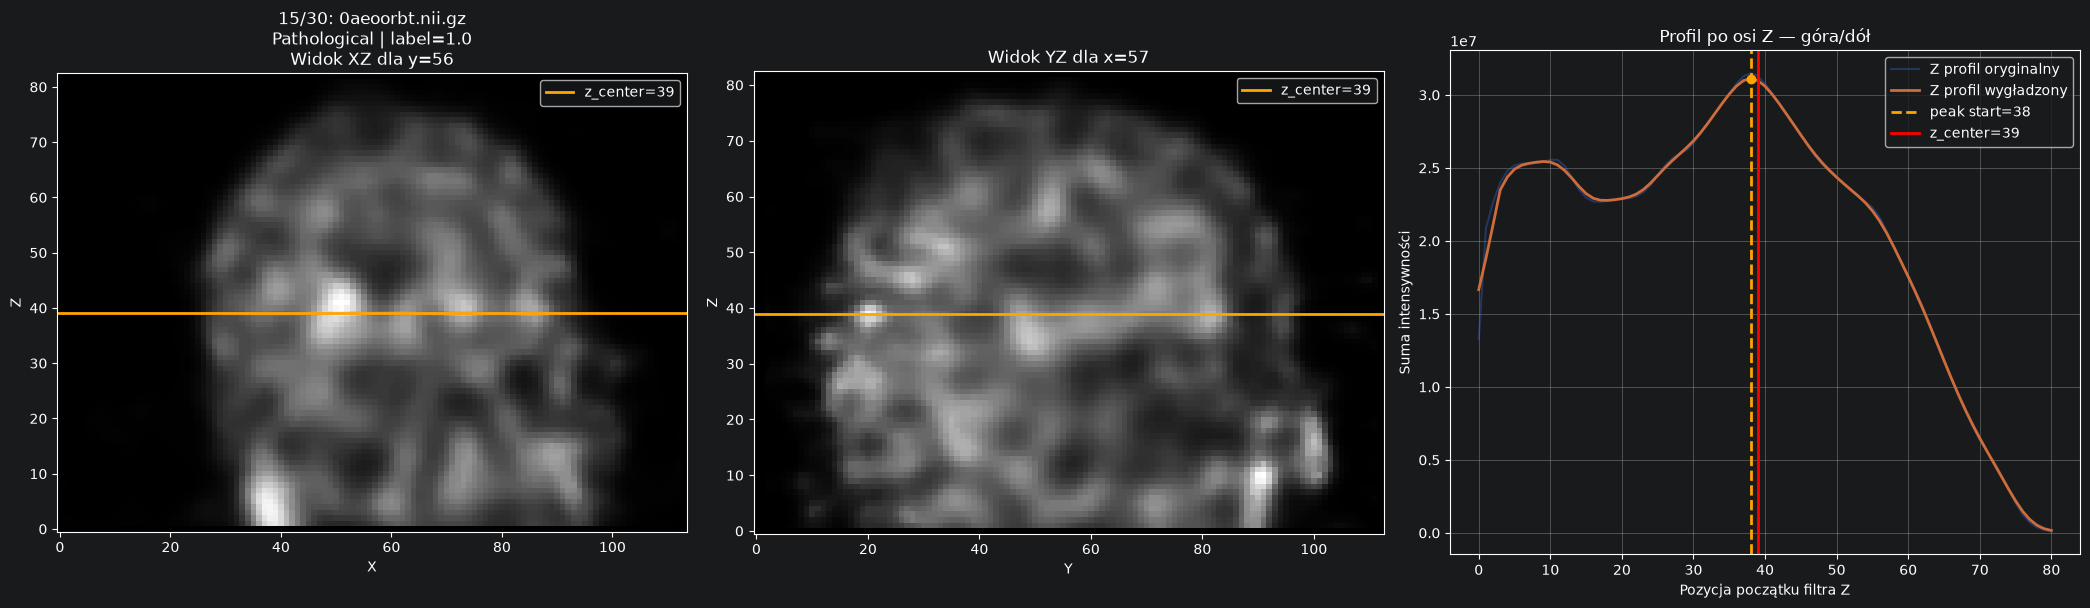

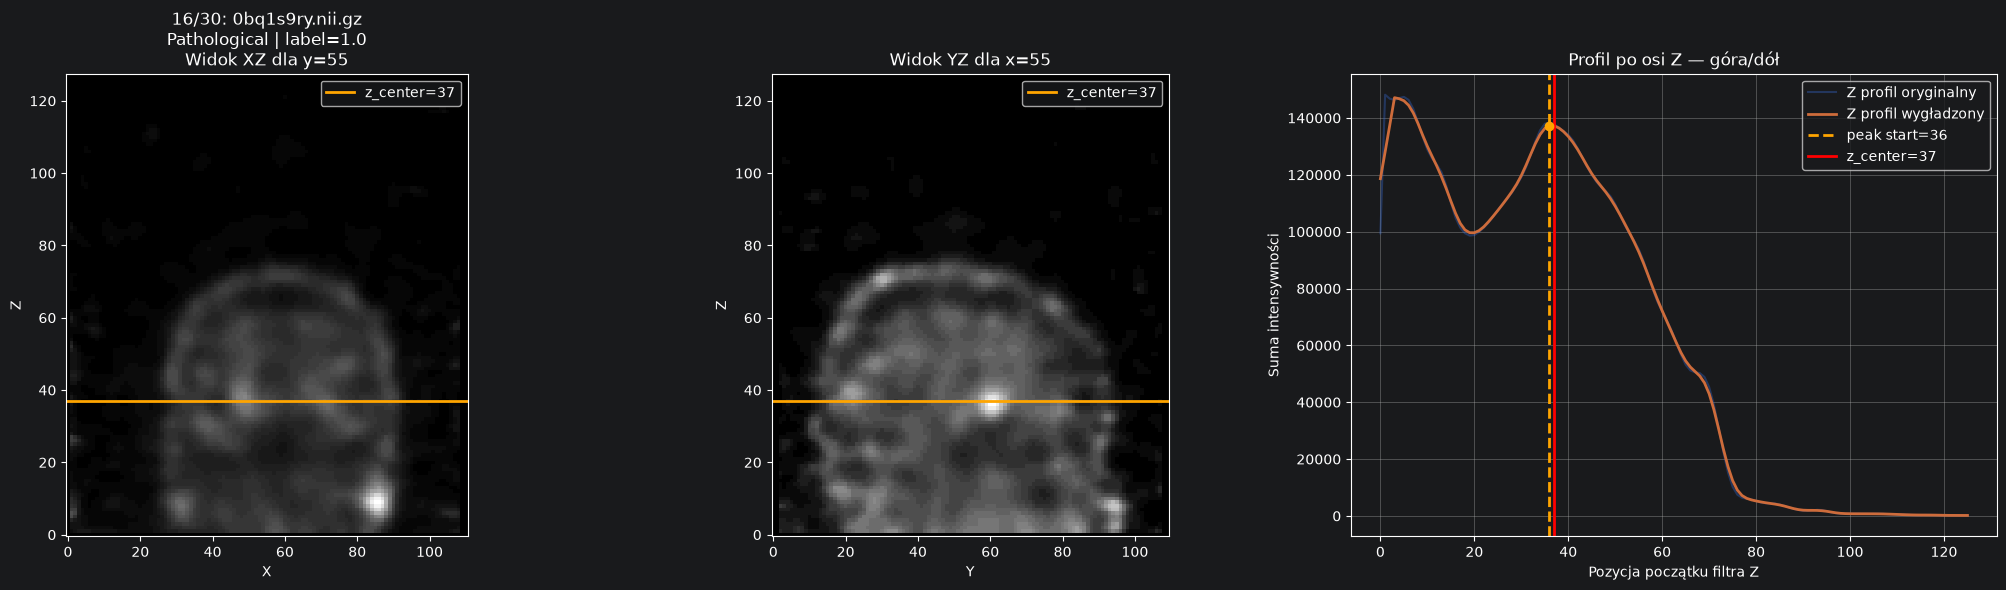

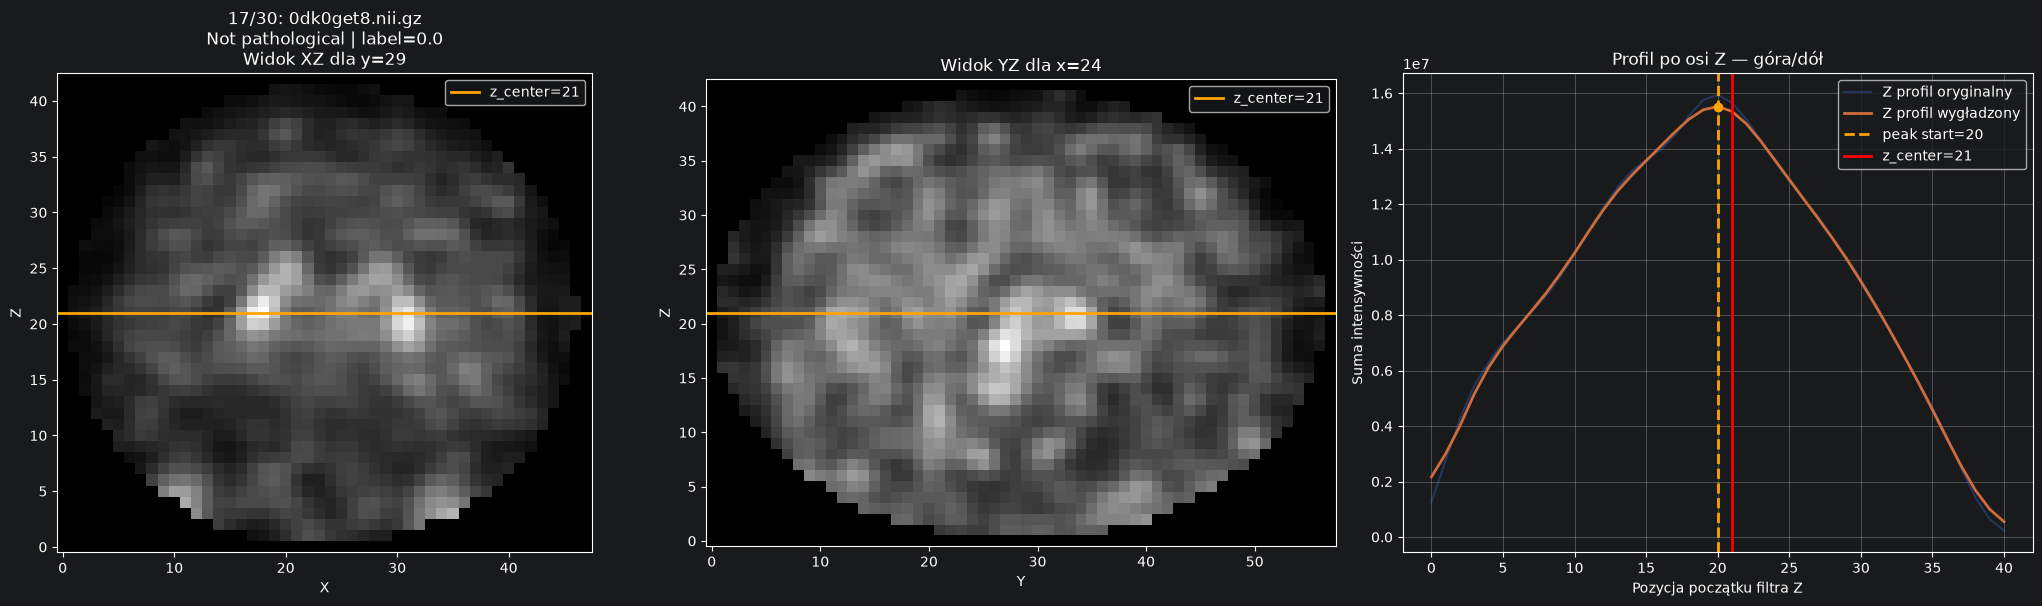

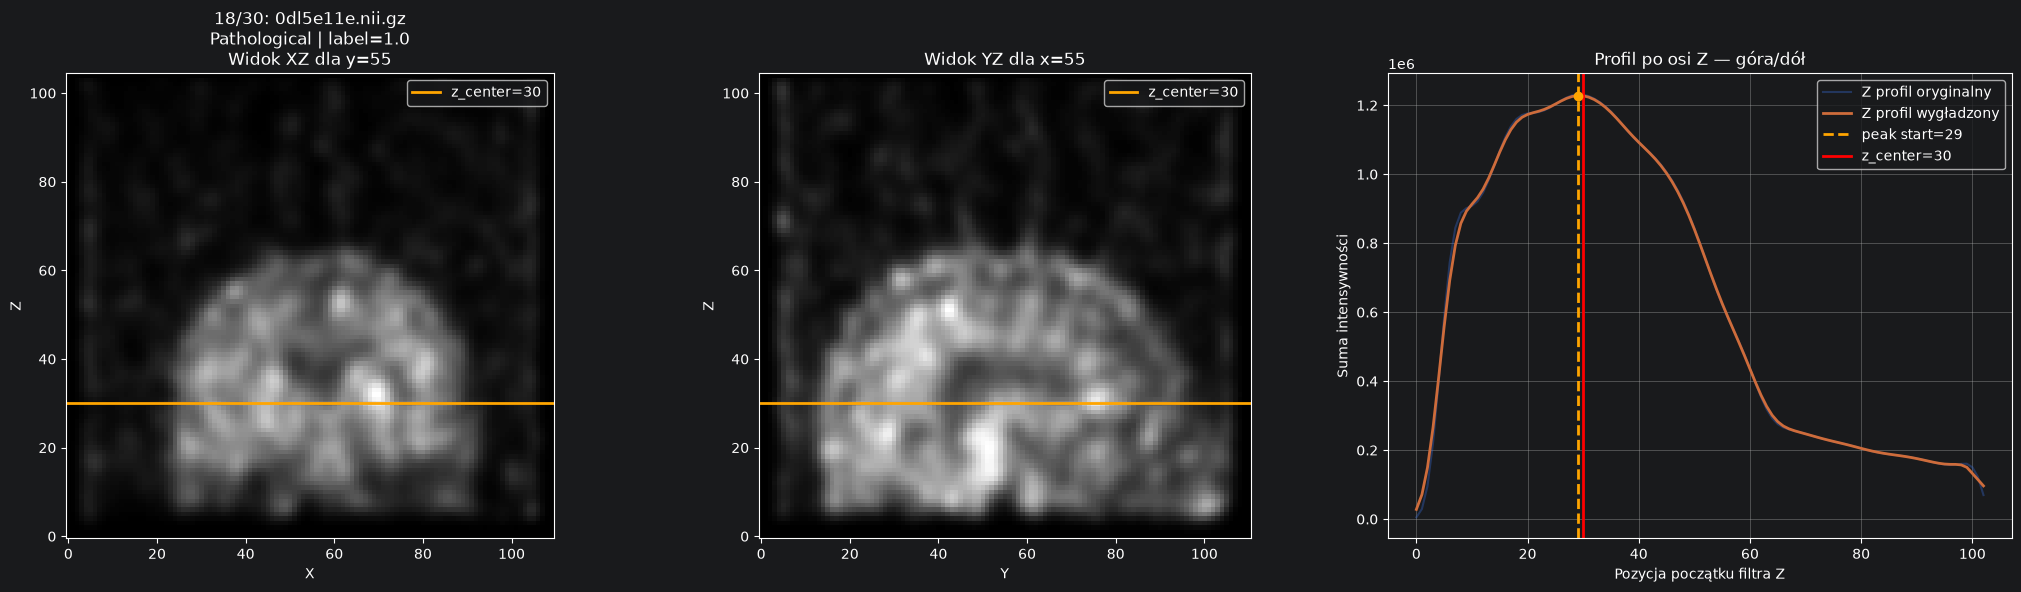

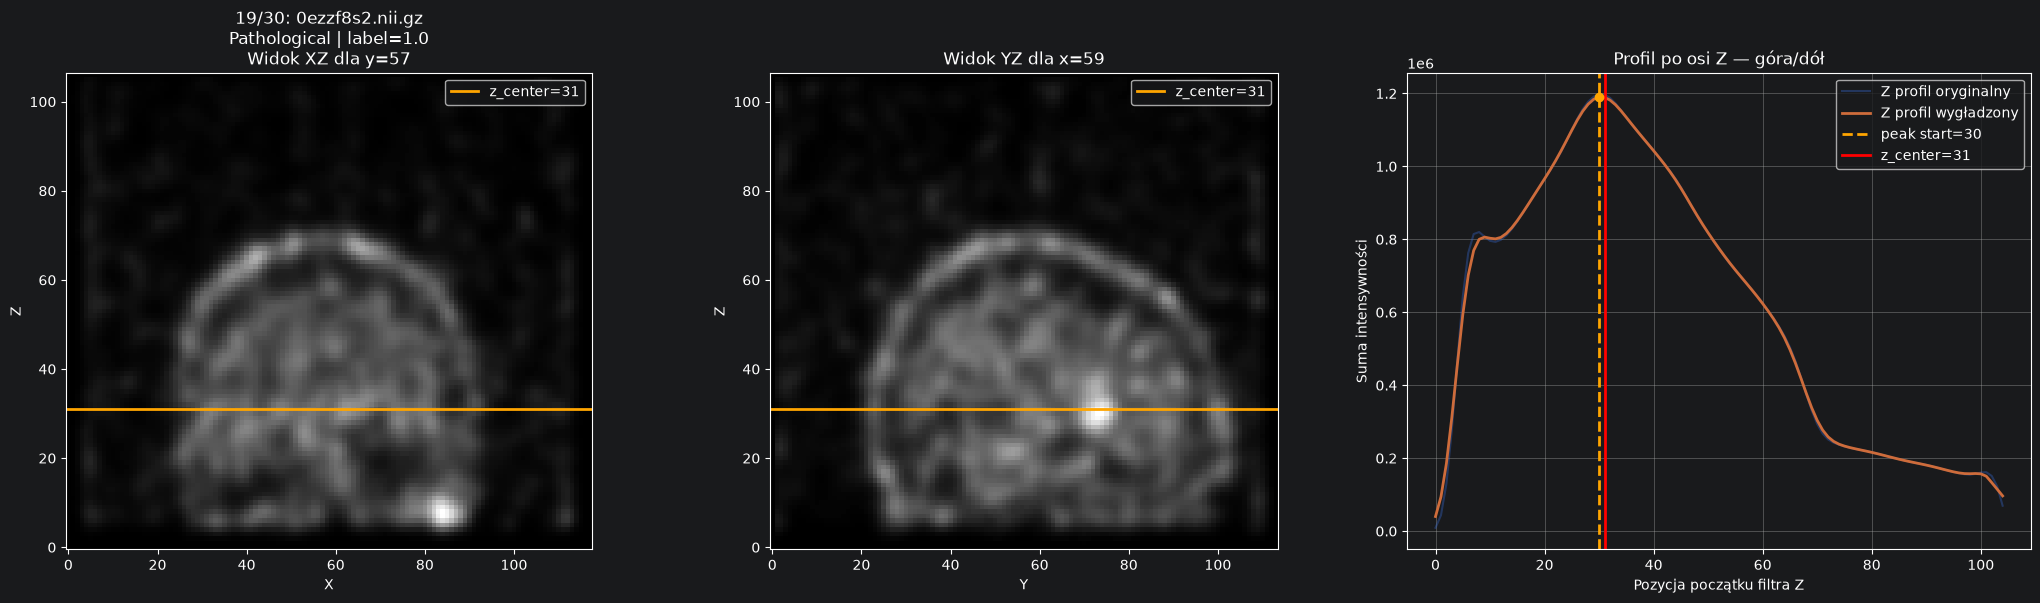

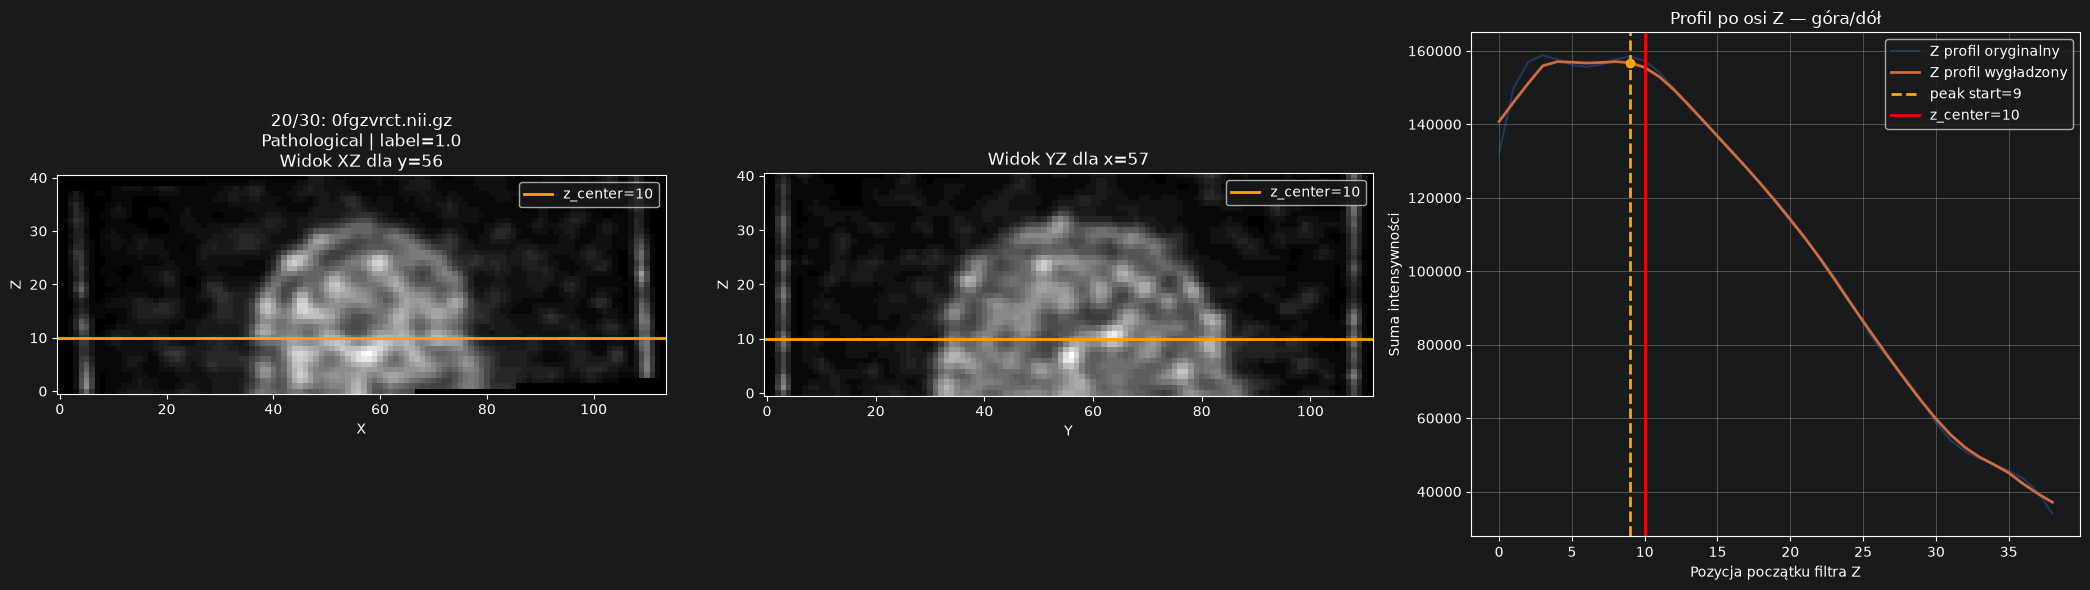

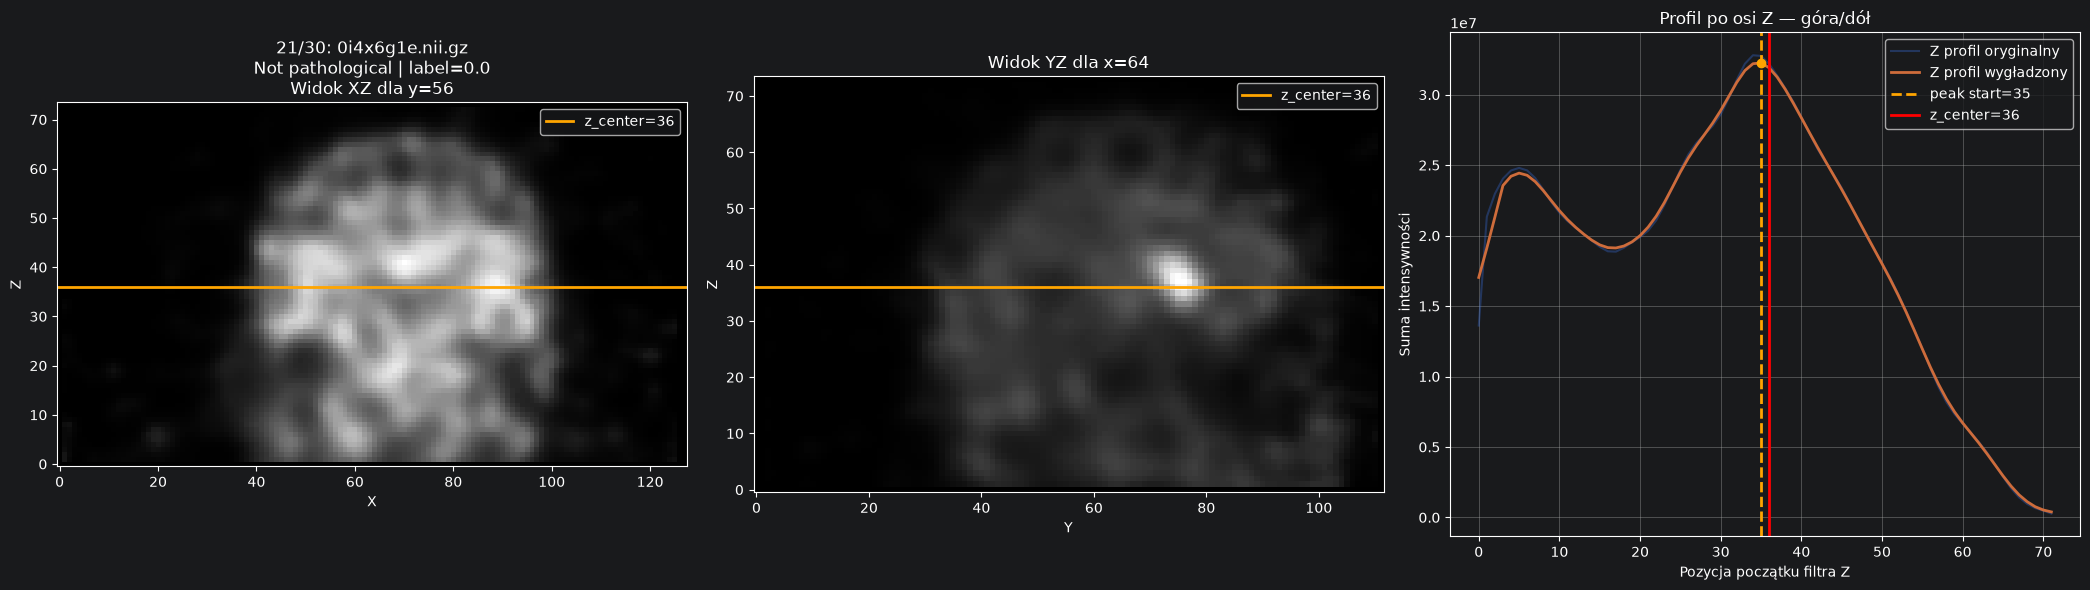

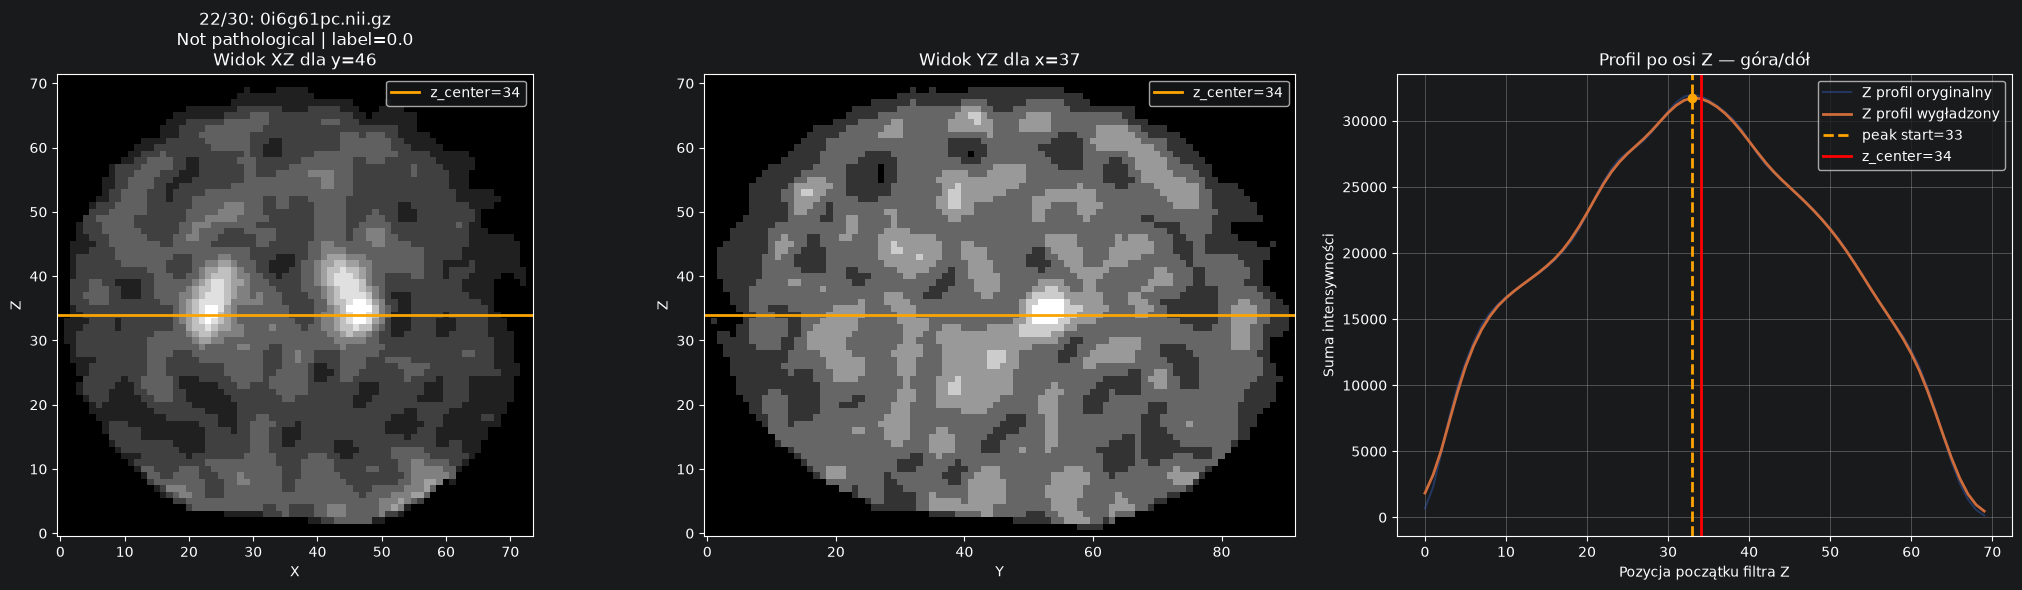

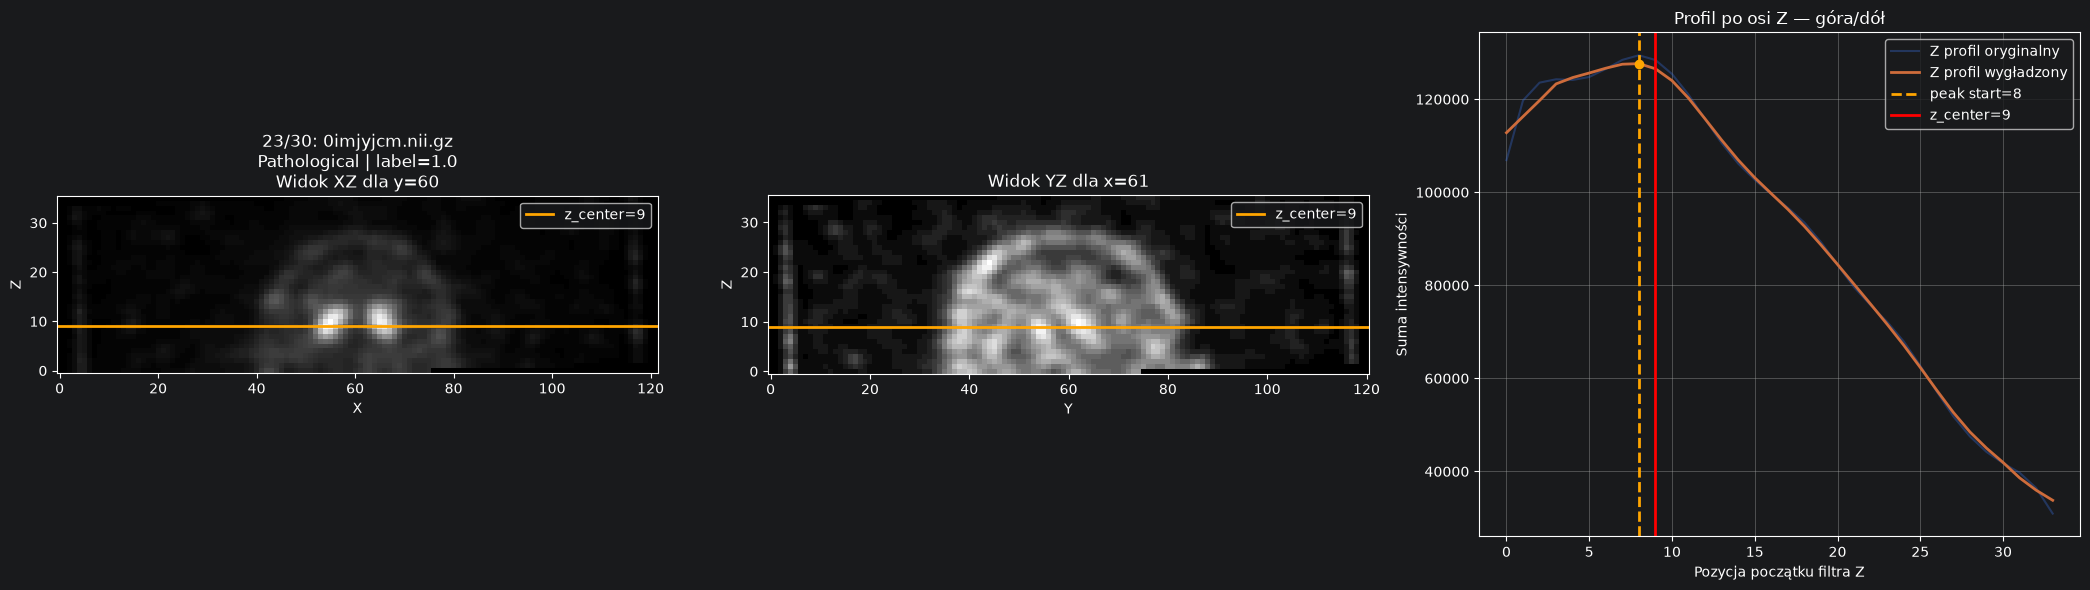

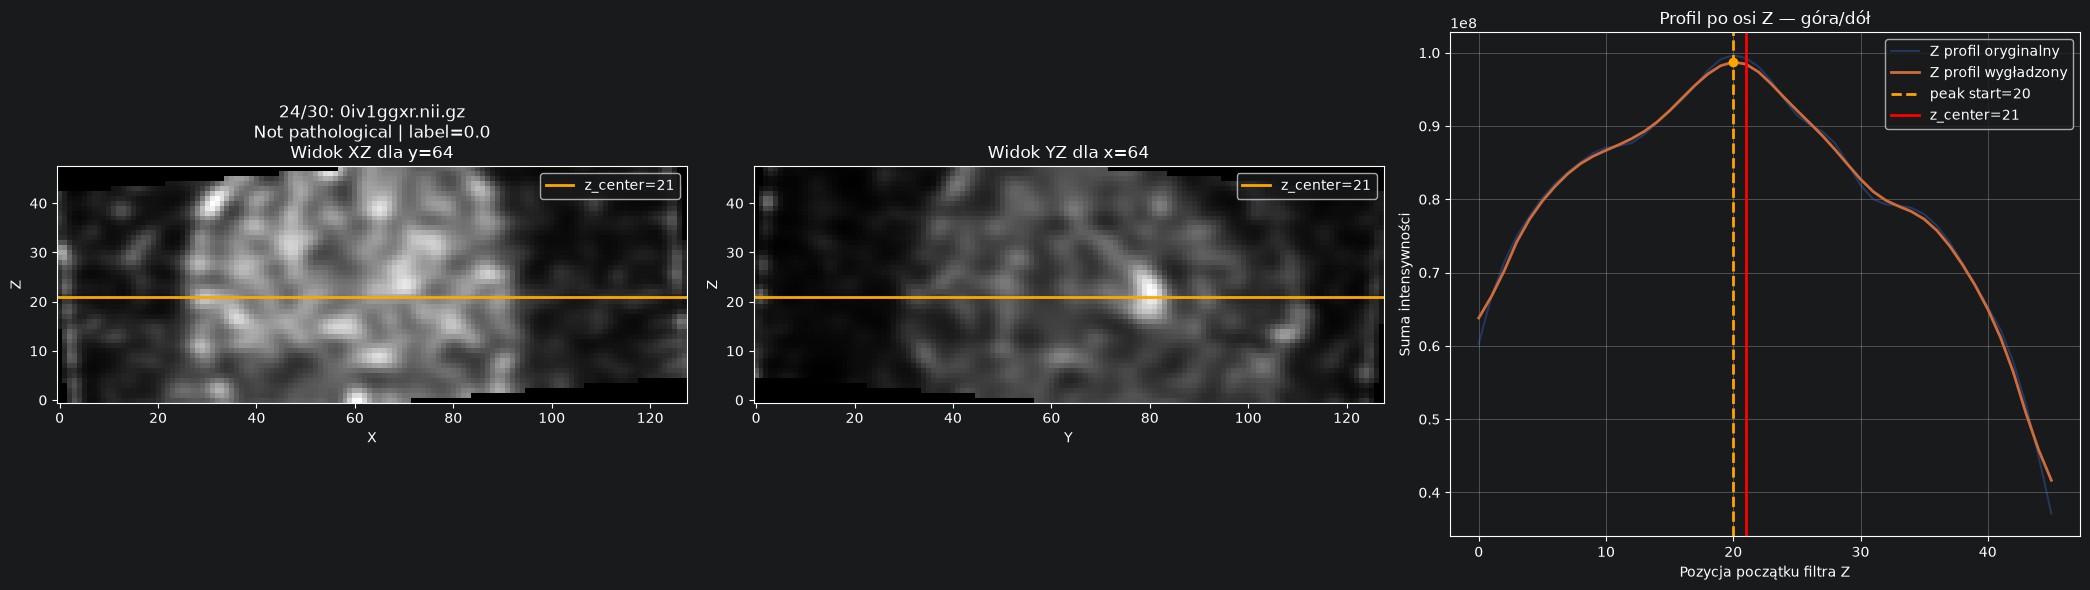

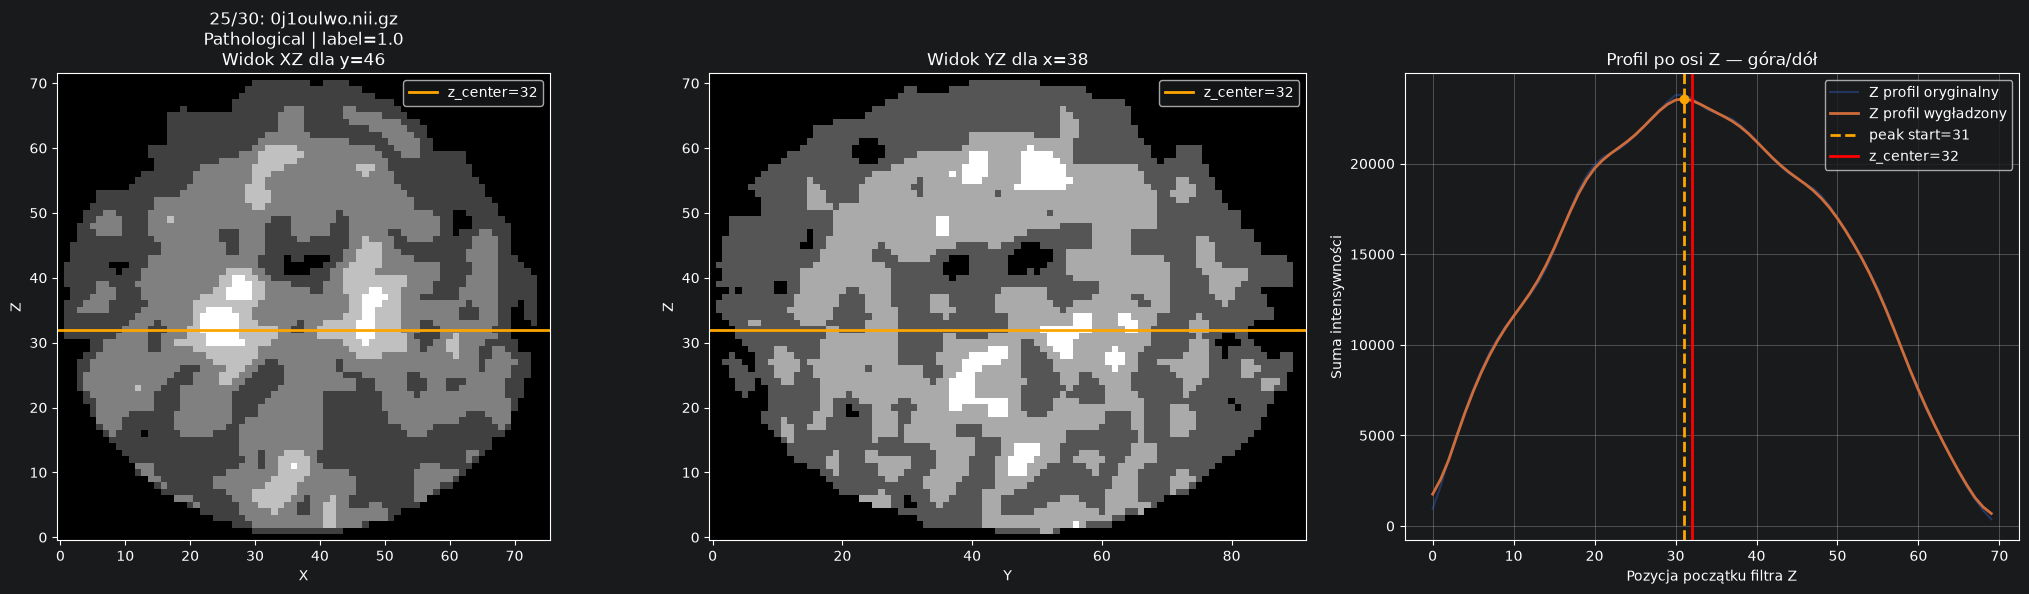

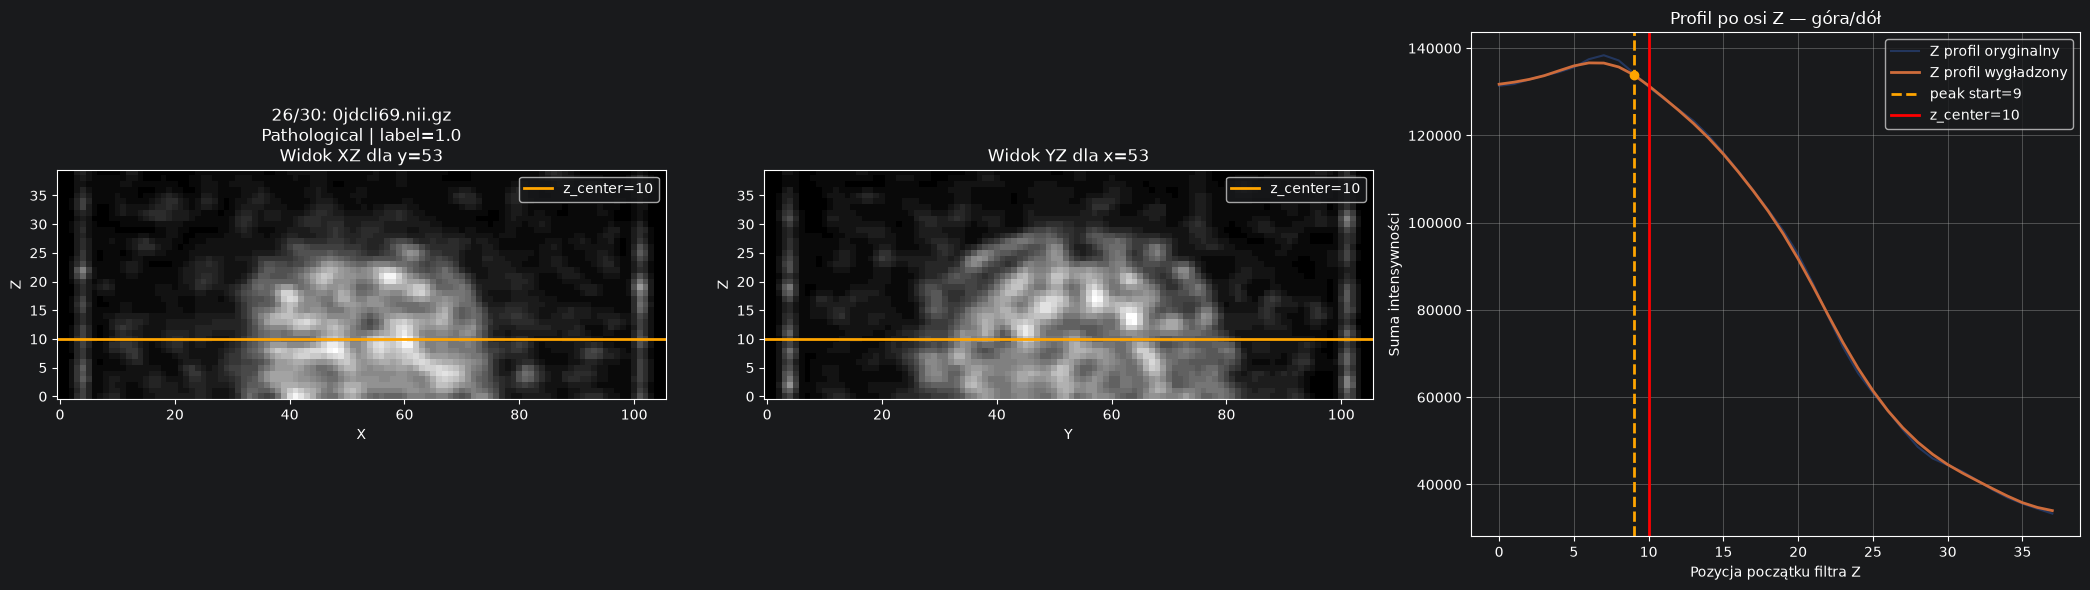

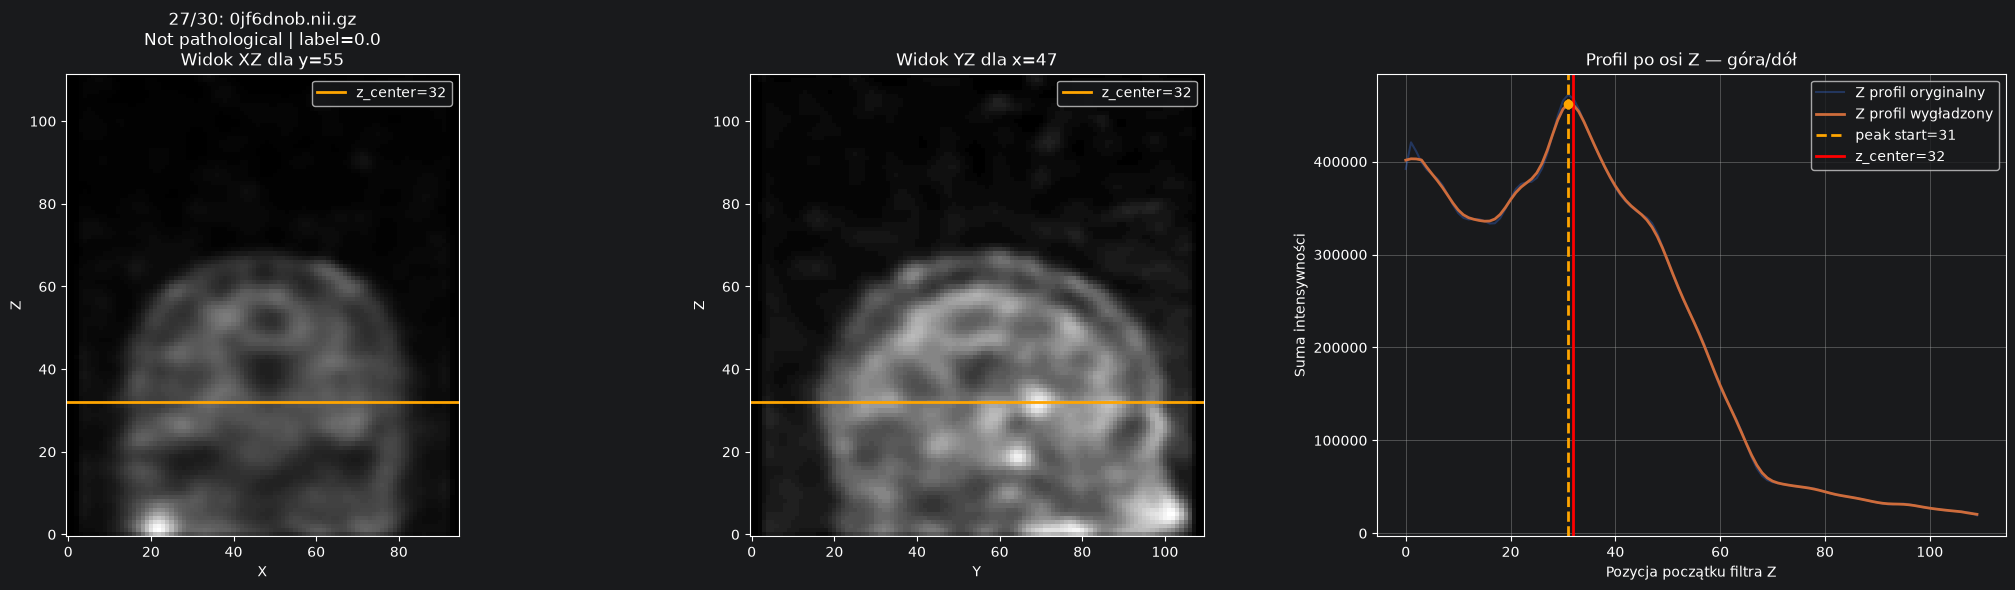

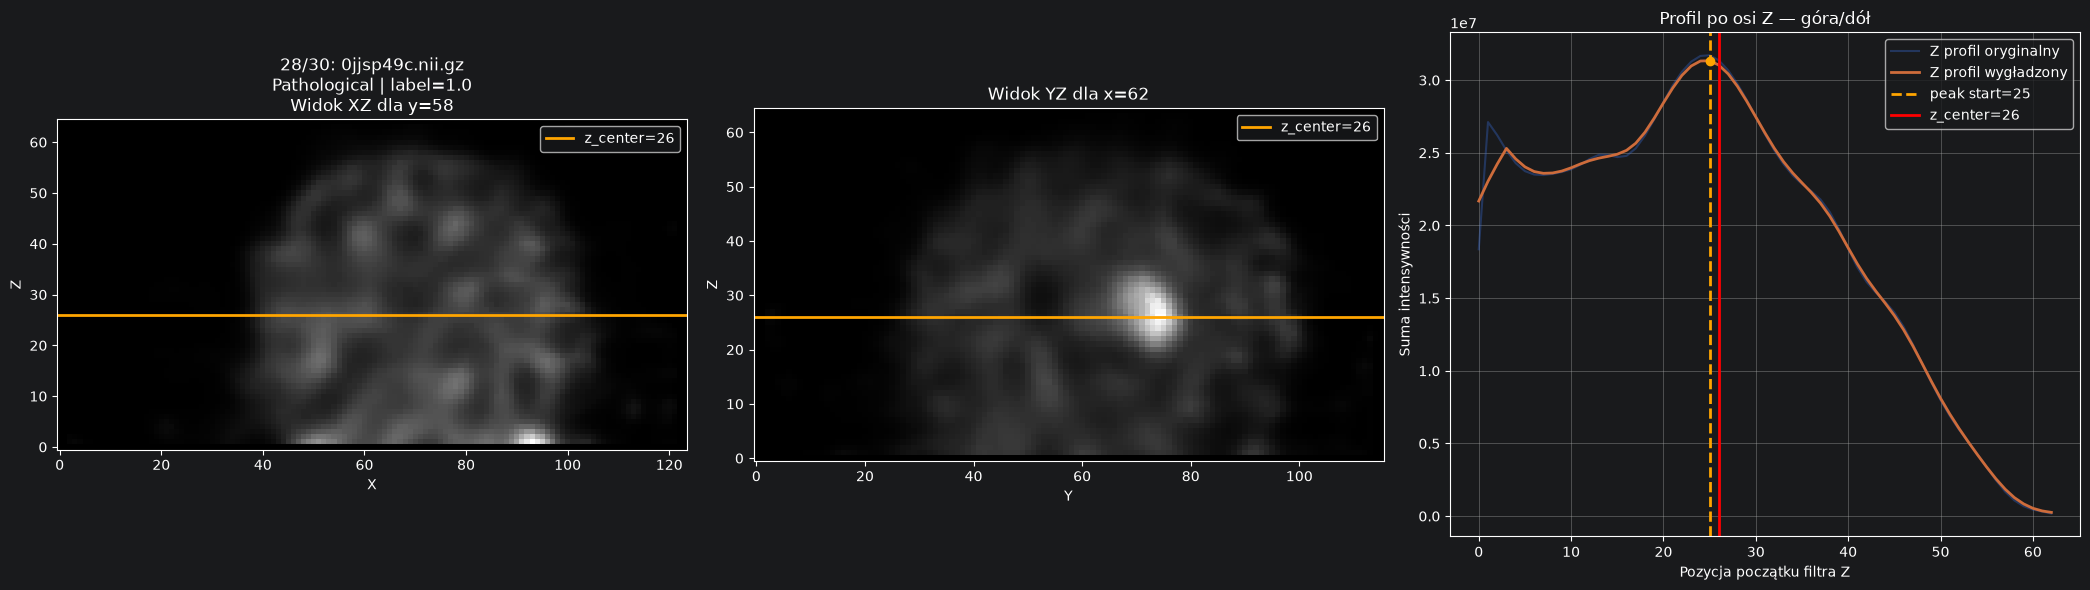

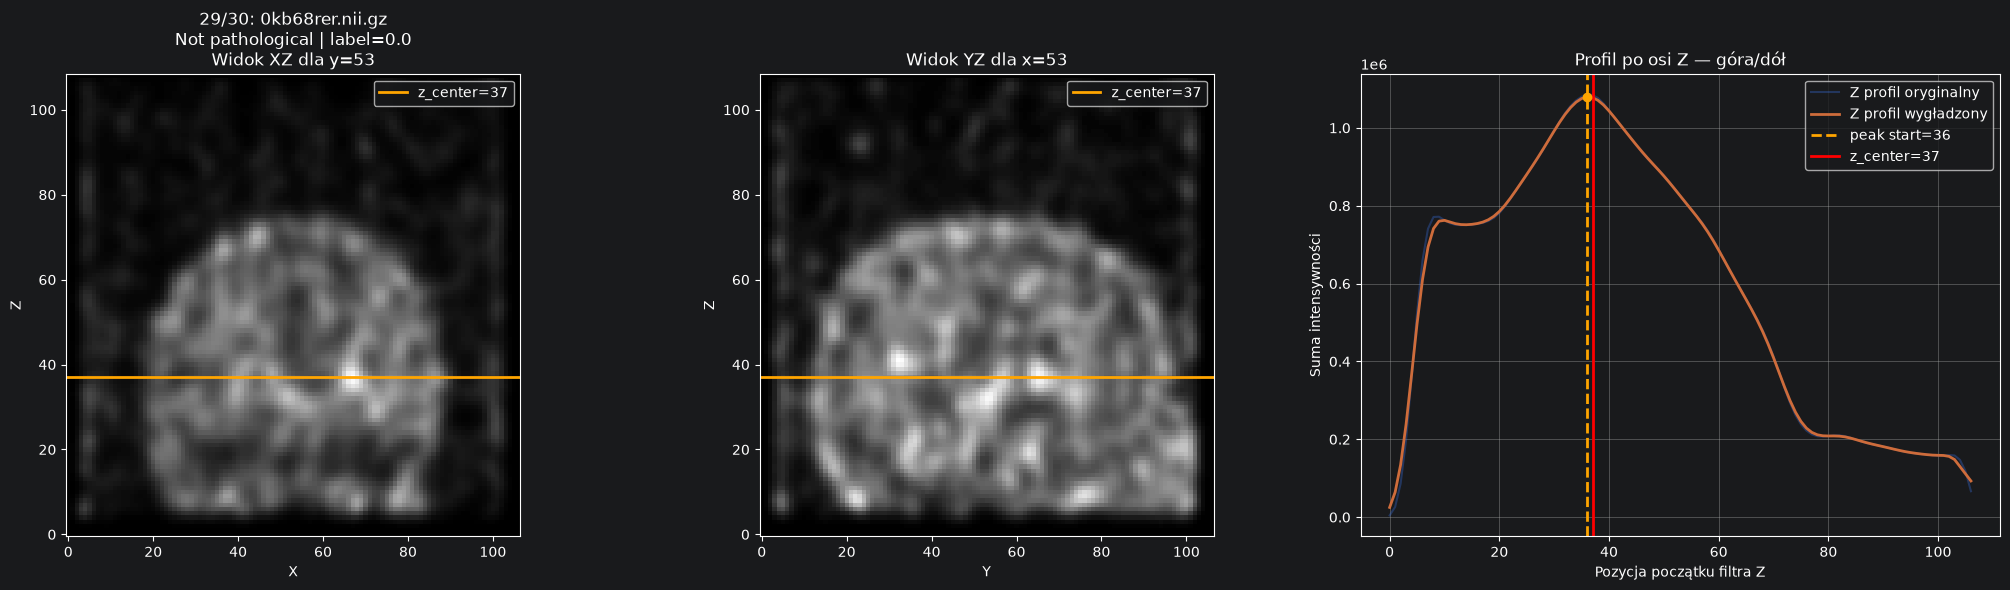

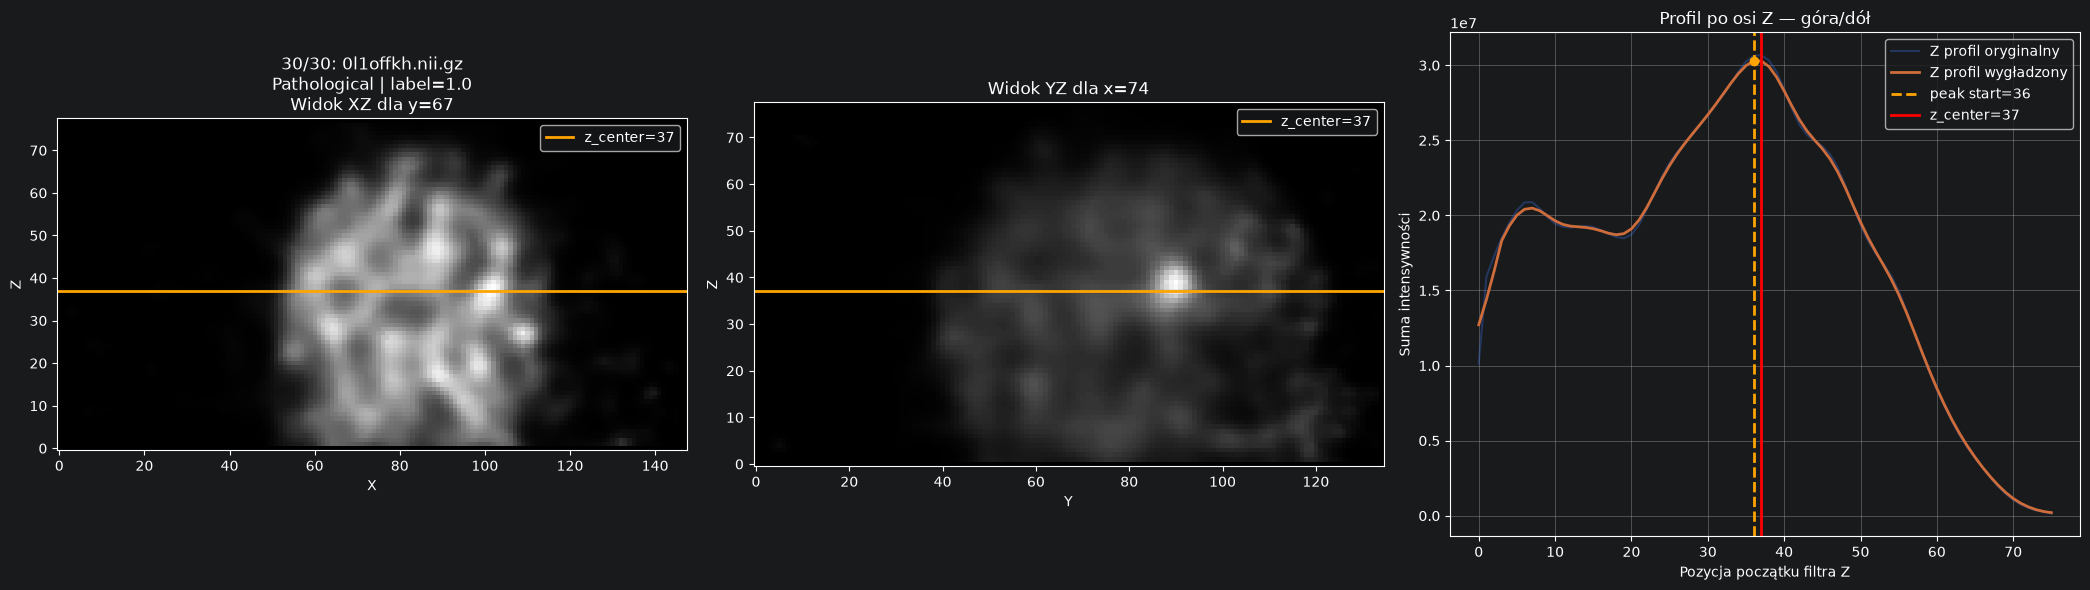

In [3]:


filter_width = 3
smooth_window = 5
n_preview = 30

for i, file_path in enumerate(files[:n_preview]):
    uid = file_path.name.replace(".nii.gz", "")
    target = target_map.get(uid)
    diagnosis = "Pathological" if target == 1 else "Not pathological"

    cropped, _ = cut_off_black_segments(
        path=file_path,
        threshold=0,
        margin=1,
    )


    z_profile = calculate_z_profile(
        cropped,
        filter_width=filter_width
    )

    # z_center = find_z_center(
    #     cropped,
    #     # filter_width=filter_width,
    #     # smooth_window=smooth_window
    # )
    z_center =find_z_argmax(z_profile,filter_width=filter_width,smooth_window=smooth_window)

    z_peak_start = z_center - filter_width // 2

    smoothed = smooth_1d(
        z_profile,
        window_size=smooth_window
    )

    x_mid = cropped.shape[0] // 2
    y_mid = cropped.shape[1] // 2

    fig, axes = plt.subplots(1, 3, figsize=(21, 6))

    axes[0].imshow(
        cropped[:, y_mid, :].T,
        cmap="gray",
        origin="lower"
    )
    axes[0].axhline(
        z_center,
        color="orange",
        linewidth=2,
        label=f"z_center={z_center}"
    )
    axes[0].set_title(
        f"{i + 1}/{n_preview}: {file_path.name}\n"
        f"{diagnosis} | label={target}\n"
        f"Widok XZ dla y={y_mid}"
    )
    axes[0].set_xlabel("X")
    axes[0].set_ylabel("Z")
    axes[0].legend()

    axes[1].imshow(
        cropped[x_mid, :, :].T,
        cmap="gray",
        origin="lower"
    )
    axes[1].axhline(
        z_center,
        color="orange",
        linewidth=2,
        label=f"z_center={z_center}"
    )
    axes[1].set_title(
        f"Widok YZ dla x={x_mid}"
    )
    axes[1].set_xlabel("Y")
    axes[1].set_ylabel("Z")
    axes[1].legend()

    axes[2].plot(
        z_profile,
        alpha=0.35,
        label="Z profil oryginalny"
    )
    axes[2].plot(
        smoothed,
        linewidth=2,
        label="Z profil wygładzony"
    )

    axes[2].axvline(
        z_peak_start,
        color="orange",
        linestyle="--",
        linewidth=2,
        label=f"peak start={z_peak_start}"
    )

    axes[2].axvline(
        z_center,
        color="red",
        linewidth=2,
        label=f"z_center={z_center}"
    )

    axes[2].scatter(
        [z_peak_start],
        [smoothed[z_peak_start]],
        color="orange",
        zorder=5
    )

    axes[2].set_title("Profil po osi Z — góra/dół")
    axes[2].set_xlabel("Pozycja początku filtra Z")
    axes[2].set_ylabel("Suma intensywności")
    axes[2].grid(True)
    axes[2].legend()

    plt.tight_layout()
    plt.show()